# Dyad Position Predictor
Train a neural network to predict dyad positions on a per-position basis from encoded DNA sequences (0-7).

## 1. Imports and setup
Load core libraries (NumPy, PyTorch, Matplotlib), utilities, and project helpers used throughout the notebook.

In [1]:
import sys
from pathlib import Path

# Add nuctool directory to path for imports
nuctool_path = Path.cwd().parent / 'nuctool'
if str(nuctool_path) not in sys.path:
    sys.path.insert(0, str(nuctool_path))

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
from tqdm import tqdm
import json
import os

from ChromatinFibers import simulate_chromatin_fibers, SimulationParams, read_simulation_results
from Plotter import Plotter

plotter = Plotter()

FIG_SIZE = (15, 4)  # standard figure size: width fixed, height may vary for imshow/tall panels


## 2. Simulation parameters and output paths
Choose how many samples to simulate and define file paths for saving the model and generated data.

In [2]:
n_samples = 15000
data_filename = rf"data/LLM models/LLM_tests/test_2_{n_samples}.h5"


model_filename = rf"data/LLM models/LLM_tests/test_2_{n_samples}_fitted_variables.pt"

## 2a. Simulation new data
Only if not enough data is available, simulate new data.

In [3]:
if Path(data_filename).exists():
    data_simulation_params = read_simulation_results(data_filename)
    if data_simulation_params.n_samples < n_samples:
        simulation_params = data_simulation_params
        simulation_params.n_samples = n_samples - data_simulation_params.n_samples
        simulate_chromatin_fibers(simulation_params, data_filename)
else:
    simulation_params = SimulationParams(n_samples=n_samples, amplitude=0.05, chemical_potential_kT=8, padding_bp=1000, motifs=["A", "T"], strand="both"
    , efficiency=0.2)
    simulate_chromatin_fibers(simulation_params, data_filename)

simulation_params = read_simulation_results(data_filename)
print("Simulation parameters:")
for key, value in simulation_params.__dict__.items():
    print(f"  {key}: {value}")

Simulation parameters:
  n_samples: 15000
  length_bp: 10000
  amplitude: 0.05
  period_bp: 10.0
  chemical_potential_kT: 8.0
  e_contact_kT: -0.5
  motifs: ['A', 'T']
  strand: both
  efficiency: 0.2
  steric_exclusion_bp: 0
  padding_bp: 1000


## 3. Model architecture visualization
Define and render a step-by-step diagram explaining how the model transforms an input sequence into per-position dyad probabilities.

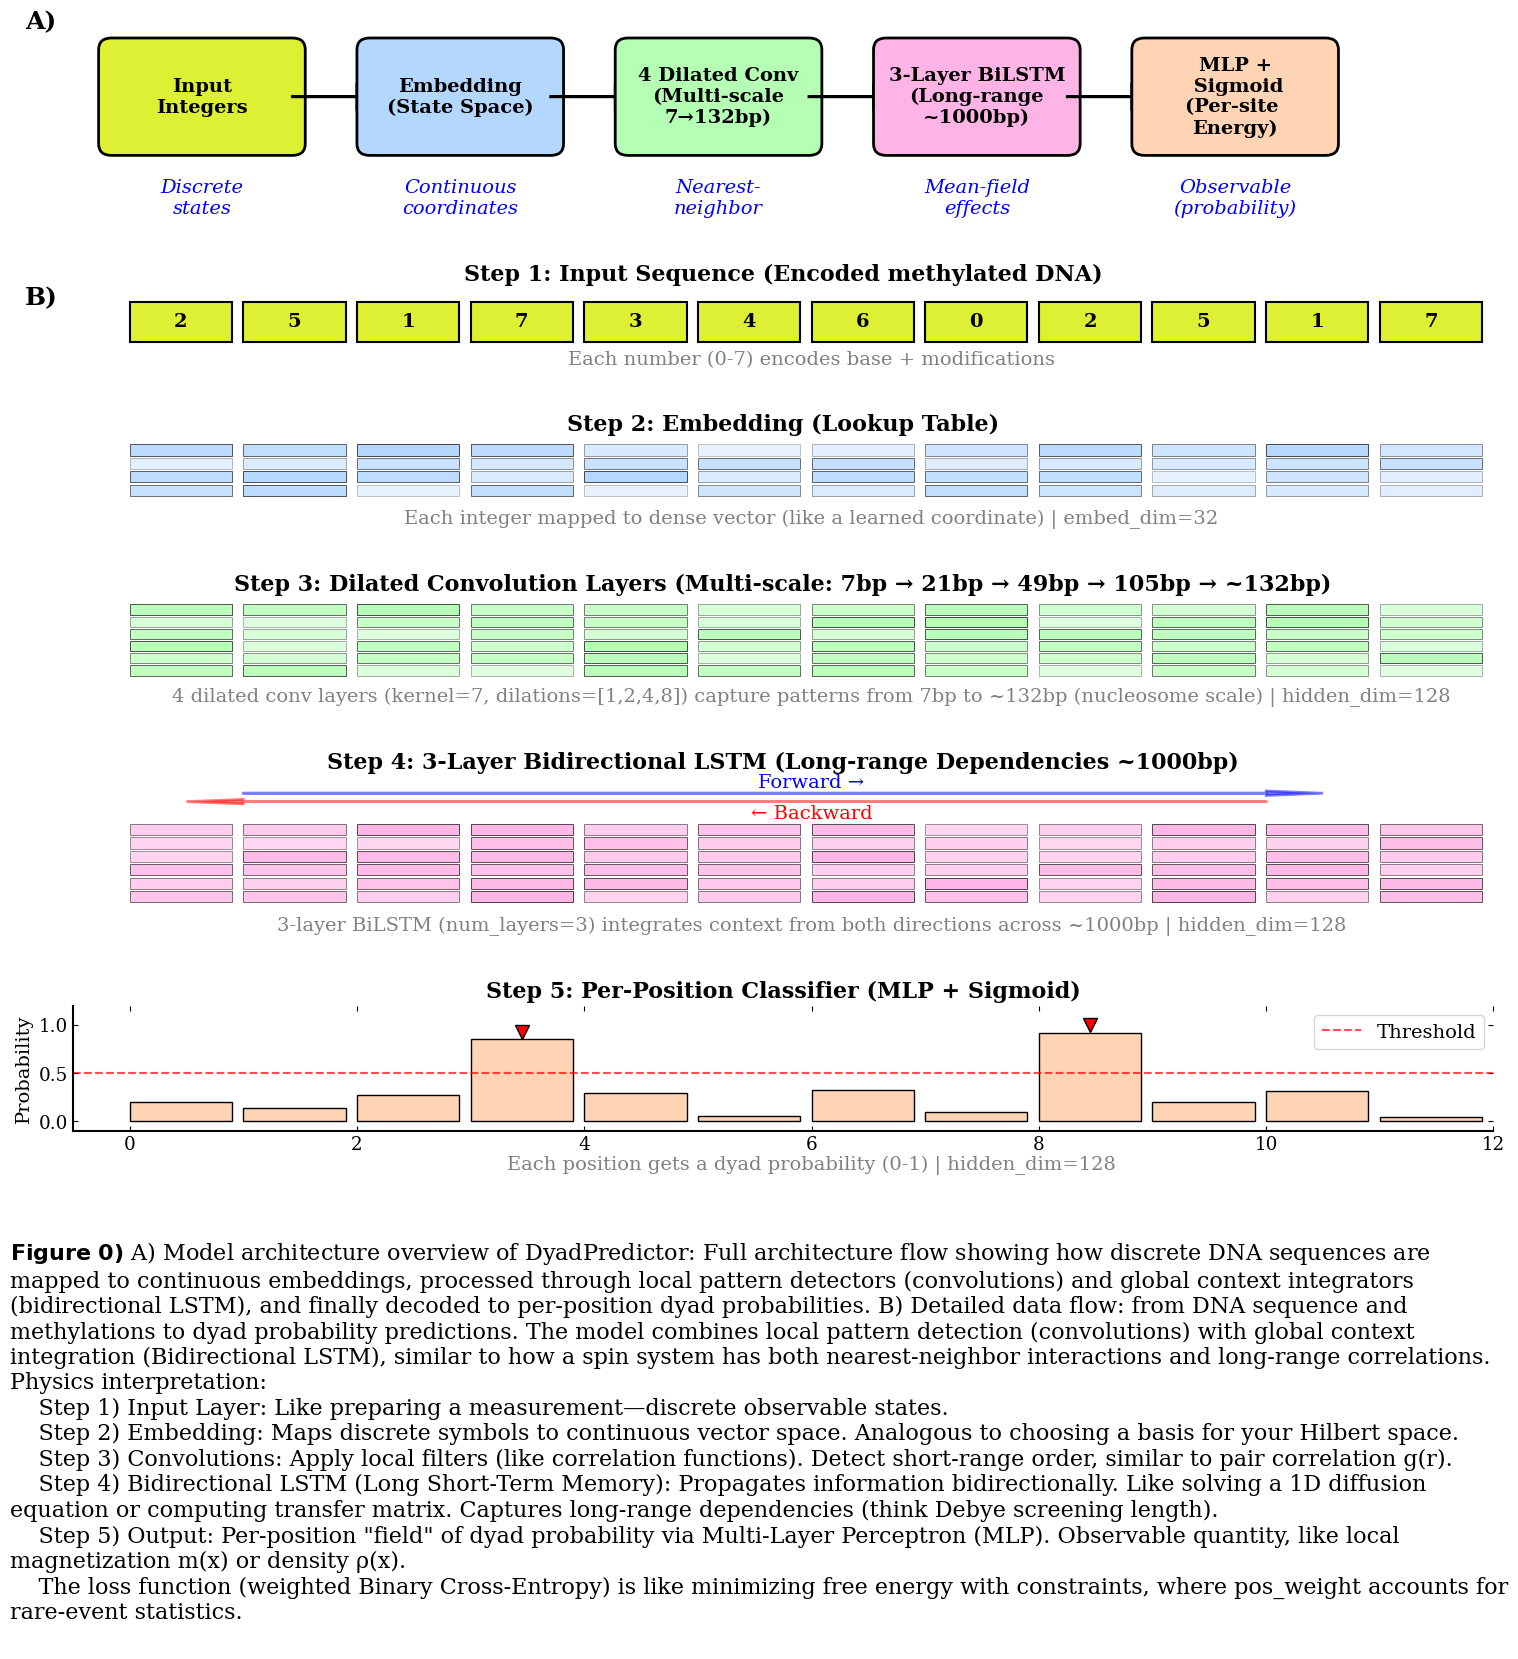

In [4]:
# Visualization of the LLM; diagram of data flow through the model
# not required for full operation

import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec


def visualize_model_forward_pass(sequence_length=100):
    """
    Create a visual diagram showing how data flows through the DILATED model.
    Uses a toy example with shapes to illustrate transformations.
    Architecture: 4 dilated conv layers + 3-layer BiLSTM for 132 bp motifs and 1000 bp correlations.
    """
    
    # Model hyperparameters (matching the DILATED model)
    embedding_dim = 32
    hidden_dim = 128

    # Shared box geometry for Steps 2–4
    BOX_HEIGHT = 0.20
    ROW_STEP = 0.24  # vertical step between rows
    
    # Use constrained_layout to avoid tight_layout warnings and improve spacing
    fig = plt.figure(figsize=(FIG_SIZE[0], 12), constrained_layout=True)
    # Reorder: summary diagram at top (rows 0-1), then steps 1-5 (rows 2-7)
    gs = GridSpec(8, 3, figure=fig, height_ratios=[1.5, 1.5, 1, 1, 1.3, 2.1, 2, 0.2])
    # Increase vertical space between rows (steps)
    fig.set_constrained_layout_pads(w_pad=0.05, h_pad=0.05, hspace=0.3, wspace=0.2)
    
    # Define colors for different stages
    colors = {
        'input': "#DDF033",      # Light yellow
        'embed': '#B4D7FF',      # Light blue
        'conv': '#B4FFB4',       # Light green
        'lstm': '#FFB4E5',       # Light pink
        'output': '#FFD4B4'      # Light orange
    }
    
    # ========== Summary Diagram (NOW AT TOP) ==========
    ax_summary = fig.add_subplot(gs[0:2, :])
    fig.text(0.01, 1.0, 'A)', fontsize=18, fontweight='bold', va='top')
    ax_summary.axis('off')
    
    # Create flow diagram
    boxes = [
        ('Input\nIntegers', 0.5, colors['input']),
        ('Embedding\n(State Space)', 1.5, colors['embed']),
        ('4 Dilated Conv\n(Multi-scale\n7→132bp)', 2.5, colors['conv']),
        ('3-Layer BiLSTM\n(Long-range\n~1000bp)', 3.5, colors['lstm']),
        ('MLP +\n Sigmoid\n(Per-site \nEnergy)', 4.5, colors['output'])
    ]
    
    for label, x, color in boxes:
        rect = mpatches.FancyBboxPatch((x-0.35, 0.5), 0.7, 0.4, 
                                       boxstyle="round,pad=0.05", 
                                       facecolor=color, 
                                       edgecolor='black', linewidth=2)
        ax_summary.add_patch(rect)
        ax_summary.text(x, 0.7, label, ha='center', va='center', 
                fontsize=14, fontweight='bold')
        
        if x < 4.5:
            ax_summary.arrow(x+0.35, 0.7, 0.25, 0, head_width=0.1, head_length=0.08, 
                     fc='black', ec='black', linewidth=2)
    
    # Add physics analogies
    label_height = 0.35
    analogies = [
        (0.5, label_height, 'Discrete\nstates'),
        (1.5, label_height, 'Continuous\ncoordinates'),
        (2.5, label_height, 'Nearest-\nneighbor'),
        (3.5, label_height, 'Mean-field\neffects'),
        (4.5, label_height, 'Observable\n(probability)')
    ]
    
    for x, y, text in analogies:
        ax_summary.text(x, y, text, ha='center', va='top', 
                fontsize=14, style='italic', color='blue')
    
    ax_summary.set_xlim(0, 5.5)
    ax_summary.set_ylim(0.25, 1.05)
    
    # ========== 1. Input Sequence ==========
    ax1 = fig.add_subplot(gs[2, :])
    ax1.set_title('Step 1: Input Sequence (Encoded methylated DNA)', fontsize=16, fontweight='bold')
    fig.text(0.01, 0.77, 'B)', fontsize=18, fontweight='bold', va='top')
    
    # Show a small example sequence
    example_seq = [2, 5, 1, 7, 3, 4, 6, 0, 2, 5, 1, 7]
    n_show = len(example_seq)
    
    for i, val in enumerate(example_seq):
        rect = mpatches.Rectangle((i, 0), 0.9, 0.9, 
                                  facecolor=colors['input'], 
                                  edgecolor='black', linewidth=1.5)
        ax1.add_patch(rect)
        ax1.text(i + 0.45, 0.45, str(val), 
                ha='center', va='center', fontsize=14, fontweight='bold')
    
    ax1.set_xlim(-0.5, n_show)
    ax1.set_ylim(-0.2, 1.2)
    ax1.axis('off')
    ax1.text(n_show/2, -0.5, 'Each number (0-7) encodes base + modifications', 
            ha='center', fontsize=14, color='gray')
    
    # ========== 2. Embedding Layer ==========
    ax2 = fig.add_subplot(gs[3, :])
    ax2.set_title('Step 2: Embedding (Lookup Table)', fontsize=16, fontweight='bold')
    
    # Show embedding as small vertical bars (uniform height)
    embed_rows = 4
    for i in range(n_show):
        for j in range(embed_rows):  # Show 4 dimensions for visualization
            intensity = np.random.rand() * 0.7 + 0.3
            y0 = j * ROW_STEP
            rect = mpatches.Rectangle((i, y0), 0.9, BOX_HEIGHT, 
                                      facecolor=colors['embed'], 
                                      edgecolor='black', linewidth=0.5,
                                      alpha=intensity)
            ax2.add_patch(rect)
    
    ax2.set_xlim(-0.5, n_show)
    ax2.set_ylim(-0.1, ROW_STEP*(embed_rows-1) + BOX_HEIGHT + 0.1)
    ax2.axis('off')
    ax2.text(n_show/2, -0.5, f'Each integer mapped to dense vector (like a learned coordinate) | embed_dim={embedding_dim}', 
            ha='center', fontsize=14, color='gray')
    
    # ========== 3. Dilated Conv Layers (4 layers, multi-scale) ==========
    ax3 = fig.add_subplot(gs[4, :])
    ax3.set_title('Step 3: Dilated Convolution Layers (Multi-scale: 7bp → 21bp → 49bp → 105bp → ~132bp)', 
                 fontsize=16, fontweight='bold')
    
    # Show dilated convolution as sparse receptive fields
    kernel_size = 7
    dilations = [1, 2, 4, 8]  # Four dilation rates
    conv_rows = 6
    y_max3 = ROW_STEP*(conv_rows-1) + BOX_HEIGHT
    
    # Show receptive field for the most dilated layer (dilation=8)
    for i in range(0, n_show - (kernel_size-1)*dilations[-1], 10):  # Show every 10th for clarity
        # Highlight positions touched by dilated kernel
        for k in range(kernel_size):
            pos = i + k*dilations[-1]
            if pos < n_show:
                rect_bg = mpatches.Rectangle((pos, 0), 0.9, y_max3, 
                                             facecolor='yellow', alpha=0.5, 
                                             edgecolor='red', linewidth=1.5, linestyle='--')
                ax3.add_patch(rect_bg)
    
    for i in range(n_show):
        for j in range(conv_rows):
            intensity = np.random.rand() * 0.6 + 0.4
            y0 = j * ROW_STEP
            rect = mpatches.Rectangle((i, y0), 0.9, BOX_HEIGHT, 
                                      facecolor=colors['conv'], 
                                      edgecolor='black', linewidth=0.5,
                                      alpha=intensity)
            ax3.add_patch(rect)
    
    ax3.set_xlim(-0.5, n_show)
    ax3.set_ylim(-0.1, y_max3 + 0.1)
    ax3.axis('off')
    ax3.text(n_show/2, -0.5, f'4 dilated conv layers (kernel=7, dilations=[1,2,4,8]) capture patterns from 7bp to ~132bp (nucleosome scale) | hidden_dim={hidden_dim}', 
            ha='center', fontsize=14, color='gray')
    
    # ========== 4. 3-Layer BiLSTM ==========
    ax4 = fig.add_subplot(gs[5, :])
    ax4.set_title('Step 4: 3-Layer Bidirectional LSTM (Long-range Dependencies ~1000bp)', 
                 fontsize=16, fontweight='bold')
    
    lstm_rows = 6
    y_max4 = ROW_STEP*(lstm_rows-1) + BOX_HEIGHT*4
    # Show information flow with arrows
    for i in range(n_show):
        for j in range(lstm_rows):
            intensity = np.random.rand() * 0.5 + 0.5
            y0 = j * ROW_STEP
            rect = mpatches.Rectangle((i, y0), 0.9, BOX_HEIGHT, 
                                      facecolor=colors['lstm'], 
                                      edgecolor='black', linewidth=0.5,
                                      alpha=intensity)
            ax4.add_patch(rect)
    
    # Draw arrows showing bidirectional flow (positioned near the top of the band)
    arrow_y = max(0.15, y_max4 - 0.05)
    ax4.arrow(1, arrow_y, n_show-3, 0, head_width=0.08, head_length=0.5, 
             fc='blue', ec='blue', alpha=0.5, linewidth=2)
    ax4.arrow(n_show-2, arrow_y-0.15, -(n_show-3), 0, head_width=0.08, head_length=0.5, 
             fc='red', ec='red', alpha=0.5, linewidth=2)
    
    ax4.text(n_show/2, arrow_y+0.1, 'Forward →', ha='center', fontsize=14, color='blue')
    ax4.text(n_show/2, arrow_y-0.45, '← Backward', ha='center', fontsize=14, color='red')
    
    ax4.set_xlim(-0.5, n_show)
    ax4.set_ylim(-0.1, y_max4 + 0.25)
    ax4.axis('off')
    ax4.text(n_show/2, -0.5, f'3-layer BiLSTM (num_layers=3) integrates context from both directions across ~1000bp | hidden_dim={hidden_dim}', 
            ha='center', fontsize=14, color='gray')
    
    # ========== 5. Output Layer ==========
    ax5 = fig.add_subplot(gs[6, :])
    ax5.set_title('Step 5: Per-Position Classifier (MLP + Sigmoid)', 
                 fontsize=16, fontweight='bold')
    
    # Show output as probability bars
    np.random.seed(42)
    probs = np.random.beta(2, 10, n_show)  # Skewed distribution (most low, few high)
    probs[[3, 8]] = [0.85, 0.92]  # Make two positions "dyads"
    
    for i in range(n_show):
        # Probability bar
        rect = mpatches.Rectangle((i, 0), 0.9, probs[i], 
                                  facecolor=colors['output'], 
                                  edgecolor='black', linewidth=1)
        ax5.add_patch(rect)
        
        # Mark high-confidence predictions
        if probs[i] > 0.5:
            ax5.plot(i + 0.45, probs[i] + 0.08, 'v', 
                    color='red', markersize=10, markeredgecolor='black')
    
    ax5.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Threshold')
    ax5.set_xlim(-0.5, n_show)
    ax5.set_ylim(-0.1, 1.2)
    ax5.set_ylabel('Probability', fontsize=14)
    ax5.spines['top'].set_visible(False)
    ax5.spines['right'].set_visible(False)
    ax5.spines['left'].set_linewidth(1.5)
    ax5.spines['bottom'].set_linewidth(1.5)
    ax5.text(n_show/2, -0.5, f'Each position gets a dyad probability (0-1) | hidden_dim={hidden_dim}', 
            ha='center', fontsize=14, color='gray')
    ax5.legend(loc='upper right', fontsize=14)
    
    caption = "A) Model architecture overview of DyadPredictor: Full architecture flow showing how discrete DNA sequences are mapped to continuous embeddings, processed through local pattern detectors (convolutions) and global context integrators (bidirectional LSTM), and finally decoded to per-position dyad probabilities. B) Detailed data flow: from DNA sequence and methylations to dyad probability predictions. "
    caption += "The model combines local pattern detection (convolutions) with global context integration (Bidirectional LSTM), "
    caption += "similar to how a spin system has both nearest-neighbor interactions and long-range correlations. Physics interpretation: "
    caption += """
    Step 1) Input Layer: Like preparing a measurement—discrete observable states.
    Step 2) Embedding: Maps discrete symbols to continuous vector space. Analogous to choosing a basis for your Hilbert space.
    Step 3) Convolutions: Apply local filters (like correlation functions). Detect short-range order, similar to pair correlation g(r).
    Step 4) Bidirectional LSTM (Long Short-Term Memory): Propagates information bidirectionally. Like solving a 1D diffusion equation or computing transfer matrix. Captures long-range dependencies (think Debye screening length).
    Step 5) Output: Per-position "field" of dyad probability via Multi-Layer Perceptron (MLP). Observable quantity, like local magnetization m(x) or density ρ(x).
    The loss function (weighted Binary Cross-Entropy) is like minimizing free energy with constraints, where pos_weight accounts for rare-event statistics.
    """

    plotter.caption(caption)

    return fig

# Create the visualization
fig = visualize_model_forward_pass(sequence_length=100)

## 4. Verify data file exists
Check that the HDF5 data file exists from the simulation in the previous cell. Load simulation parameters from the file.

In [5]:
# Verify HDF5 data file exists and load parameters
if Path(data_filename).exists():
    print(f"Data file verified: {data_filename}")
    
    # Load simulation parameters from HDF5 file
    loaded_params = read_simulation_results(data_filename)
    print("\nLoaded simulation parameters:")
    for key, value in loaded_params.__dict__.items():
        print(f"  {key}: {value}")
    
    # Write simulation parameters to JSON config for reference
    config_path = Path(model_filename).with_suffix(".json")
    
    if config_path.exists():
        with open(config_path, "r") as f:
            existing_config = json.load(f)
    else:
        existing_config = {}
    
    existing_config["simulation"] = loaded_params.__dict__
    
    with open(config_path, "w") as f:
        json.dump(existing_config, f, indent=4)
    
    print(f"\nConfig saved to: {config_path}")
else:
    raise FileNotFoundError(f"Data file not found: {data_filename}. Run the simulation cell first.")

Data file verified: data/LLM models/LLM_tests/test_2_15000.h5

Loaded simulation parameters:
  n_samples: 15000
  length_bp: 10000
  amplitude: 0.05
  period_bp: 10.0
  chemical_potential_kT: 8.0
  e_contact_kT: -0.5
  motifs: ['A', 'T']
  strand: both
  efficiency: 0.2
  steric_exclusion_bp: 0
  padding_bp: 1000

Config saved to: data/LLM models/LLM_tests/test_2_15000_fitted_variables.json


## 5. Define model architecture (PyTorch) - DILATED VERSION
Build the DyadPredictor network with dilated convolutions for 132 bp motifs and deeper BiLSTM for 1000 bp correlations.

In [6]:
class DyadPredictor(nn.Module):
    """Per-position dyad predictor using dilated Conv1d and bidirectional context.
    
    Architecture optimized for:
    - 132 bp nucleosome positioning motifs (via dilated convolutions)
    - 1000 bp long-range correlations (via deeper BiLSTM)
    """

    def __init__(
        self, vocab_size=8, embedding_dim=32, hidden_dim=128, num_layers=3, dropout=0.3
    ):
        super().__init__()
        self.vocab_size = vocab_size

        # Embedding layer (map 0-7 to dense vectors)
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        # Dilated conv blocks for multi-scale pattern detection (5 bp → 132 bp)
        # Layer 1: receptive field ~7 bp
        self.conv1 = nn.Conv1d(embedding_dim, hidden_dim, kernel_size=7, padding=3, dilation=1)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        
        # Layer 2: receptive field ~21 bp
        self.conv2 = nn.Conv1d(hidden_dim, hidden_dim, kernel_size=7, padding=6, dilation=2)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        
        # Layer 3: receptive field ~49 bp
        self.conv3 = nn.Conv1d(hidden_dim, hidden_dim, kernel_size=7, padding=12, dilation=4)
        self.bn3 = nn.BatchNorm1d(hidden_dim)
        
        # Layer 4: receptive field ~105 bp (captures full nucleosome ~132 bp with neighbors)
        self.conv4 = nn.Conv1d(hidden_dim, hidden_dim, kernel_size=7, padding=24, dilation=8)
        self.bn4 = nn.BatchNorm1d(hidden_dim)

        # BiLSTM for global context (132 bp → 1000 bp correlations)
        self.lstm = nn.LSTM(
            hidden_dim,
            hidden_dim // 2,
            num_layers=num_layers,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True,
        )

        # Output head
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, x):
        """Forward pass.
        Args:
            x: (batch_size, seq_len) - encoded sequence
        Returns:
            logits: (batch_size, seq_len, 1) - per-position dyad logits
        """
        # Embedding: (batch, seq_len) -> (batch, seq_len, embed_dim)
        x = self.embedding(x)

        # Dilated conv blocks: (batch, seq_len, embed_dim) -> (batch, embed_dim, seq_len)
        x = x.transpose(1, 2)
        
        x = self.conv1(x)
        x = self.bn1(x)
        x = torch.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = torch.relu(x)
        
        x = self.conv3(x)
        x = self.bn3(x)
        x = torch.relu(x)
        
        x = self.conv4(x)
        x = self.bn4(x)
        x = torch.relu(x)

        # Back to (batch, seq_len, hidden_dim)
        x = x.transpose(1, 2)

        # LSTM: (batch, seq_len, hidden_dim) -> (batch, seq_len, hidden_dim)
        x, _ = self.lstm(x)

        # Per-position classification: (batch, seq_len, hidden_dim) -> (batch, seq_len, 1)
        logits = self.fc(x)

        return logits

## 6. Define custom Dataset (HDF5-based)
Implement a Dataset that loads samples on-demand from the HDF5 file using read_simulation_results, pads sequences, and marks padding with -1 in labels.

In [7]:
class DyadDataset(Dataset):
    """HDF5-based dataset for dyad position prediction - loads data on-demand from disk."""

    def __init__(self, data_filename, indices=None, max_seq_len=None):
        self.data_filename = data_filename
        self.indices = indices

        params = read_simulation_results(data_filename)
        self.n_total_samples = params.n_samples

        if max_seq_len is None:
            self.max_seq_len = params.length_bp
        else:
            self.max_seq_len = max_seq_len

        if self.indices is None:
            self.indices = list(range(self.n_total_samples))

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        dyad_pos, encoded_seq, _ = read_simulation_results(self.data_filename, real_idx)

        dyad_pos = np.asarray(dyad_pos, dtype=np.int64)
        encoded_seq = np.asarray(encoded_seq, dtype=np.int64)
        seq_len = len(encoded_seq)

        label = np.zeros(seq_len, dtype=np.float32)
        for pos in dyad_pos:
            if 0 <= pos < seq_len:
                label[pos] = 1.0

        seq_tensor = torch.LongTensor(encoded_seq)
        label_tensor = torch.FloatTensor(label)

        if seq_len < self.max_seq_len:
            pad_len = self.max_seq_len - seq_len
            seq_tensor = torch.nn.functional.pad(seq_tensor, (0, pad_len), value=0)
            label_tensor = torch.nn.functional.pad(label_tensor, (0, pad_len), value=-1)
        elif seq_len > self.max_seq_len:
            seq_tensor = seq_tensor[: self.max_seq_len]
            label_tensor = label_tensor[: self.max_seq_len]

        return seq_tensor, label_tensor

## 7. Create train/validation/test index splits
Derive index-based splits from the HDF5 file metadata without loading data into RAM, enabling scalable training on large datasets.

In [8]:
# Create train/val/test split using indices (no data loaded into memory yet)
# This approach scales to arbitrarily large datasets

# Get total number of samples from HDF5 file
params = read_simulation_results(data_filename)
n_total = params.n_samples

# Split indices for train/val/test
n_train = int(0.7 * n_samples)
n_val = int(0.15 * n_samples)

train_indices = list(range(n_train))
val_indices = list(range(n_train, n_train + n_val))
test_indices = list(range(n_train + n_val, n_samples))

print(f"Total samples in HDF5 file: {n_total}")
print(f"Using {n_samples} samples ({n_samples/n_total*100:.1f}%)")
print(f"Dataset split - Train: {len(train_indices)}, Val: {len(val_indices)}, Test: {len(test_indices)}")
print(f"HDF5 mode: Data will be loaded on-demand during training")

Total samples in HDF5 file: 15000
Using 15000 samples (100.0%)
Dataset split - Train: 10500, Val: 2250, Test: 2250
HDF5 mode: Data will be loaded on-demand during training


## 8. Create DataLoaders
Wrap the HDF5-based datasets in DataLoaders with batching and optional multiprocessing/pinned memory for faster throughput.

In [9]:
# Create HDF5-based datasets (data loaded on-demand, not held in RAM)
params = read_simulation_results(data_filename)
KNOWN_SEQ_LEN = params.length_bp  # padding was cropped during simulation, not stored
print(f"Sequence length: {KNOWN_SEQ_LEN} bp (simulated with {params.padding_bp} bp padding, then cropped)")

train_dataset = DyadDataset(data_filename, indices=train_indices, max_seq_len=KNOWN_SEQ_LEN)
val_dataset   = DyadDataset(data_filename, indices=val_indices,   max_seq_len=KNOWN_SEQ_LEN)
test_dataset  = DyadDataset(data_filename, indices=test_indices,  max_seq_len=KNOWN_SEQ_LEN)

batch_size = 32

cpu_count = os.cpu_count() or 2
num_workers = 0 if os.name == 'nt' else max(0, min(4, cpu_count - 1))
pin_memory = torch.cuda.is_available()

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=num_workers, persistent_workers=num_workers > 0, pin_memory=pin_memory)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False,
                          num_workers=num_workers, persistent_workers=num_workers > 0, pin_memory=pin_memory)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False,
                          num_workers=num_workers, persistent_workers=num_workers > 0, pin_memory=pin_memory)

print(f"DataLoaders: train={len(train_loader)} batches, val={len(val_loader)}, test={len(test_loader)}")
print(f"Workers: {num_workers}, pin_memory: {pin_memory}")

Sequence length: 10000 bp (simulated with 1000 bp padding, then cropped)
DataLoaders: train=329 batches, val=71, test=71
Workers: 4, pin_memory: True


## 9. Initialize model, loss, optimizer, and AMP
Move the model to the selected device, define the loss and optimizer, configure LR scheduler, and enable AMP on CUDA.

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# DILATED MODEL: Optimized for 132 bp motifs and 1000 bp correlations
model = DyadPredictor(
    vocab_size=8, embedding_dim=32, hidden_dim=128, num_layers=3, dropout=0.3
)
model = model.to(device)

# Loss function: BCEWithLogitsLoss (combines sigmoid + BCE)
pos_weight = torch.tensor([10.0]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight, reduction="none")

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
# ReduceLROnPlateau without 'verbose' for compatibility with older PyTorch versions
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3
)

# Enable mixed precision on CUDA for speed/memory savings
use_amp = torch.cuda.is_available()
# Create a GradScaler for AMP. Do NOT pass a device string as the first positional arg;
# the correct usage is torch.amp.GradScaler(enabled=...) or torch.cuda.amp.GradScaler().
scaler = torch.amp.GradScaler(enabled=use_amp)
print(f"AMP enabled: {use_amp}")

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Using device: cuda
AMP enabled: True
Model parameters: 680,833


## 10. Compute class imbalance weight (pos_weight)
Estimate pos_weight = negatives/positives using a fast sampler over the training indices to balance the BCE loss.

In [11]:
# Fast computation of pos_weight from training data (ignores padding)
from typing import Optional
import math

def compute_pos_weight(data_filename: str, indices, sample_size: Optional[int] = 500, seed: int = 42):
    """Estimate pos_weight = neg/pos quickly by sampling train indices from HDF5.

    This opens the HDF5 file and reads only the sampled sequences to count:
      - positives = number of dyad positions (len(dyad_positions[i]))
      - negatives = sequence length - positives (len(encoded_seq[i]) - positives)

    Args:
        data_filename: path to the .h5 file
        indices: iterable of indices representing the training set
        sample_size: number of samples to draw from indices (None means use all, which may be slow)
        seed: RNG seed for reproducibility

    Returns:
        torch.Tensor with shape [1], dtype float32, value = neg/pos (clamped if needed later)
    """
    rng = np.random.default_rng(seed)
    indices = np.asarray(list(indices))
    if indices.size == 0:
        raise ValueError("No indices provided to compute_pos_weight")

    if sample_size is None:
        sample_indices = indices
    else:
        k = min(int(sample_size), indices.size)
        sample_indices = rng.choice(indices, size=k, replace=False)

    pos_total = 0
    neg_total = 0
    
    # Read samples from HDF5 using read_simulation_results
    for i in sample_indices:
        dyad_positions, encoded_seq, _ = read_simulation_results(data_filename, int(i))
        
        # Count positives as number of dyad positions
        n_pos = len(dyad_positions)
        # Negatives are remaining real (unpadded) positions
        seq_len = len(encoded_seq)
        n_neg = max(seq_len - n_pos, 0)
        pos_total += n_pos
        neg_total += n_neg

    if pos_total == 0:
        # Fallback to avoid division by zero; assume at least one positive overall
        print("Warning: no positives found in sample; defaulting pos_total=1 for stability.")
        pos_total = 1

    pw = float(neg_total) / float(pos_total)
    return torch.tensor([pw], dtype=torch.float32)



# Compute and clamp pos_weight quickly using a sample of the training set
SAMPLE_SIZE_FOR_POS_WEIGHT = 500  # adjust for more accuracy vs speed
pos_weight = compute_pos_weight(data_filename, train_indices, sample_size=SAMPLE_SIZE_FOR_POS_WEIGHT).to(device)
pos_weight = torch.clamp(pos_weight, min=1.0, max=100.0)
print(f"Computed pos_weight (sample n={min(SAMPLE_SIZE_FOR_POS_WEIGHT, len(train_indices))}): {pos_weight.item():.4f}")

# Define the weighted criterion (reduction='none' so you can mask padding later)
criterion_weighted = nn.BCEWithLogitsLoss(pos_weight=pos_weight, reduction="none")

# Save LLM configuration to JSON
config_path = Path(model_filename).with_suffix(".json")
if config_path.exists():
    with open(config_path, "r") as f:
        config = json.load(f)
else:
    config = {}

config["llm"] = {
    "model_type": "dilated_convolutions",
    "vocab_size": 8,
    "embedding_dim": 32,
    "hidden_dim": 128,
    "num_layers": 3,
    "dropout": 0.3,
    "conv_layers": 4,
    "conv_kernel_size": 7,
    "conv_dilations": [1, 2, 4, 8],
    "receptive_field": "~132 bp",
    "lstm_context": "~1000 bp",
    "pos_weight": float(pos_weight.item()),
    "learning_rate": 1e-3,
    "weight_decay": 1e-5,
    "batch_size": batch_size,
    "optimizer": "Adam",
    "scheduler": "ReduceLROnPlateau",
}

with open(config_path, "w") as f:
    json.dump(config, f, indent=4)

print(f"LLM configuration saved to: {config_path}")

# Expose for REPL visibility
criterion_weighted

Computed pos_weight (sample n=500): 100.0000
LLM configuration saved to: data/LLM models/LLM_tests/test_2_15000_fitted_variables.json


BCEWithLogitsLoss()

## 11. Define training and validation loops
Implement efficient training with masking of padded positions, AMP support, gradient clipping, and early stopping.

In [12]:
def train_epoch(model, train_loader, criterion, optimizer, device, scaler=None, use_amp=False, max_batches=None):
    """Train for one epoch.
    Args:
        model, train_loader, criterion, optimizer, device: standard
        scaler: GradScaler for AMP (optional)
        use_amp: bool, enable autocast on CUDA
        max_batches: int or None, limit number of batches per epoch for faster iterations
    """
    model.train()
    total_loss = 0

    for batch_idx, (seq_batch, label_batch) in enumerate(tqdm(train_loader, desc="Training")):
        seq_batch = seq_batch.to(device, non_blocking=True)  # (batch, seq_len)
        label_batch = label_batch.to(device, non_blocking=True)  # (batch, seq_len)

        optimizer.zero_grad(set_to_none=True)

        # Forward pass
        with torch.amp.autocast('cuda', enabled=use_amp):
            logits = model(seq_batch)  # (batch, seq_len, 1)
            logits = logits.squeeze(-1)  # (batch, seq_len)

            # Compute loss (ignore padding positions with label=-1)
            loss_per_pos = criterion(logits, label_batch)  # (batch, seq_len)
            mask = (label_batch >= 0).float()  # Mask out padding
            loss = (loss_per_pos * mask).sum() / mask.sum().clamp(min=1)

        if scaler is not None and use_amp:
            scaler.scale(loss).backward()
            # Unscale for clipping
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        total_loss += loss.item()

        if max_batches is not None and (batch_idx + 1) >= max_batches:
            break

    return total_loss / max(1, (batch_idx + 1))


def validate(model, val_loader, criterion, device, use_amp=False, max_batches=None):
    """Validate model with optional batch limit."""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch_idx, (seq_batch, label_batch) in enumerate(tqdm(val_loader, desc="Validating")):
            seq_batch = seq_batch.to(device, non_blocking=True)
            label_batch = label_batch.to(device, non_blocking=True)

            with torch.amp.autocast('cuda', enabled=use_amp):
                logits = model(seq_batch)
                logits = logits.squeeze(-1)

                loss_per_pos = criterion(logits, label_batch)
                mask = (label_batch >= 0).float()
                loss = (loss_per_pos * mask).sum() / mask.sum().clamp(min=1)

            total_loss += loss.item()

            # Store for metrics
            probs = torch.sigmoid(logits)
            all_preds.append(probs.cpu().numpy())
            all_labels.append(label_batch.cpu().numpy())

            if max_batches is not None and (batch_idx + 1) >= max_batches:
                break

    return total_loss / max(1, (batch_idx + 1)), all_preds, all_labels


# Check prerequisites before training
required_vars = {
    'model': 'model',
    'train_loader': 'train_loader', 
    'val_loader': 'val_loader',
    'criterion_weighted': 'criterion_weighted',
    'optimizer': 'optimizer',
    'device': 'device',
    'scaler': 'scaler',
    'use_amp': 'use_amp',
    'model_filename': 'model_filename'
}

missing_vars = [var for var, name in required_vars.items() if var not in globals()]
if missing_vars:
    raise NameError(f"Missing required variables: {', '.join(missing_vars)}. Please run cells 3-10 in order before training.")

# Training loop (with fast-run controls)
epochs = 50  # reduce from 50 for quicker runs
train_losses = []
val_losses = []
best_val_loss = float("inf")
patience = 5
patience_counter = 0

# Limit batches per epoch for faster iteration; set to None to use full dataset
max_batches_per_epoch = 100
max_eval_batches = 50

print("Starting training...")
for epoch in range(epochs):

    train_loss = train_epoch(
        model, train_loader, criterion_weighted, optimizer, device,
        scaler=scaler, use_amp=use_amp, max_batches=max_batches_per_epoch
    )
    val_loss, _, _ = validate(
        model, val_loader, criterion_weighted, device,
        use_amp=use_amp, max_batches=max_eval_batches
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}"
    )

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Save best model
        torch.save(model.state_dict(), model_filename)
        print(f"  Saved best model to {model_filename}")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    scheduler.step(val_loss)

print("Training completed!")

Starting training...


Training:  21%|██▏       | 70/329 [00:28<01:44,  2.47it/s]


KeyboardInterrupt: 

## 12. Plot training history
Visualize training and validation loss curves to monitor convergence and detect over/underfitting.

ValueError: max() iterable argument is empty

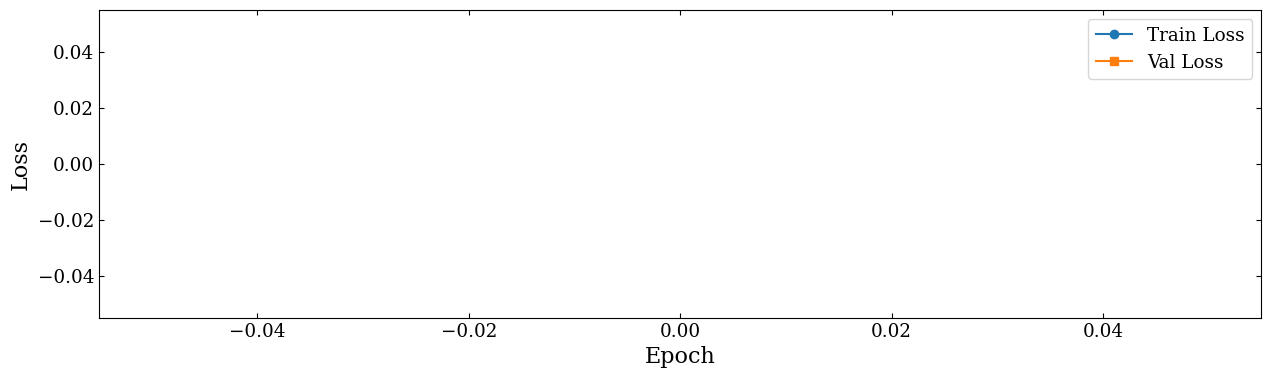

In [13]:
plt.figure(figsize=FIG_SIZE)
plt.plot(train_losses, label="Train Loss", marker="o")
plt.plot(val_losses, label="Val Loss", marker="s")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.ylim(0, max(max(train_losses), max(val_losses)) * 1.1)
plt.xlim(0, 50)
plt.tight_layout()
plotter.caption(
    f"Training history for {simulation_params.n_samples} reads and {simulation_params.length_bp} bp."
)

## 13. Evaluate on test set
Compute metrics on the held-out test data; handle padding and support sklearn or numpy fallbacks.

In [14]:
# Load best model
model.load_state_dict(torch.load(model_filename))

# Evaluate on test set
model.eval()
test_loss, test_preds, test_labels = validate(
    model, test_loader, criterion_weighted, device
)

print(f"Test Loss: {test_loss:.4f}")

# Compute metrics
all_preds_flat = np.concatenate(test_preds).ravel()
all_labels_flat = np.concatenate(test_labels).ravel()

# Remove padding positions
valid_mask = all_labels_flat >= 0
all_preds_flat = all_preds_flat[valid_mask]
all_labels_flat = all_labels_flat[valid_mask]

# Threshold at 0.3 (lower for imbalanced data with weighted loss)
predictions_binary = (all_preds_flat >= 0.3).astype(int)


# Metrics: try sklearn, fallback to numpy implementations if missing
try:
    from sklearn.metrics import (
        accuracy_score,
        precision_score,
        recall_score,
        f1_score,
        roc_auc_score,
    )

    sklearn_available = True
except Exception as e:
    sklearn_available = False
    import warnings

    warnings.warn(
        "scikit-learn not installed; using numpy fallback for basic metrics. Install with: pip install scikit-learn"
    )

    def accuracy_score(y_true, y_pred):
        y_true = np.asarray(y_true)
        y_pred = np.asarray(y_pred)
        return float((y_true == y_pred).mean())

    def precision_score(y_true, y_pred, zero_division=0):
        y_true = np.asarray(y_true)
        y_pred = np.asarray(y_pred)
        tp = int(((y_true == 1) & (y_pred == 1)).sum())
        fp = int(((y_true == 0) & (y_pred == 1)).sum())
        denom = tp + fp
        if denom == 0:
            return float(zero_division)
        return float(tp / denom)

    def recall_score(y_true, y_pred, zero_division=0):
        y_true = np.asarray(y_true)
        y_pred = np.asarray(y_pred)
        tp = int(((y_true == 1) & (y_pred == 1)).sum())
        fn = int(((y_true == 1) & (y_pred == 0)).sum())
        denom = tp + fn
        if denom == 0:
            return float(zero_division)
        return float(tp / denom)

    def f1_score(y_true, y_pred, zero_division=0):
        p = precision_score(y_true, y_pred, zero_division)
        r = recall_score(y_true, y_pred, zero_division)
        if (p + r) == 0:
            return float(zero_division)
        return 2 * (p * r) / (p + r)

    def roc_auc_score(y_true, y_score):
        y_true = np.asarray(y_true)
        y_score = np.asarray(y_score)
        # require both classes present
        if len(np.unique(y_true)) < 2:
            return float("nan")
        # Sort scores descending
        desc = np.argsort(-y_score)
        y_true_sorted = y_true[desc]
        # cumulative true/false positives
        tp = np.cumsum(y_true_sorted == 1)
        fp = np.cumsum(y_true_sorted == 0)
        tp_total = tp[-1]
        fp_total = fp[-1]
        if tp_total == 0 or fp_total == 0:
            return float("nan")
        tpr = np.concatenate([[0.0], tp / tp_total])
        fpr = np.concatenate([[0.0], fp / fp_total])
        return float(np.trapz(tpr, fpr))


# Calculate metrics
acc = accuracy_score(all_labels_flat, predictions_binary)
prec = precision_score(all_labels_flat, predictions_binary, zero_division=0)
rec = recall_score(all_labels_flat, predictions_binary, zero_division=0)
f1 = f1_score(all_labels_flat, predictions_binary, zero_division=0)
auc = roc_auc_score(all_labels_flat, all_preds_flat)

print(f"\nTest Metrics:")
print(f"  Accuracy:  {acc:.4f}")
print(f"  Precision: {prec:.4f}")
print(f"  Recall:    {rec:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print(f"  ROC-AUC:   {auc:.4f}")

# Save test metrics to JSON
config_path = Path(model_filename).with_suffix(".json")
if config_path.exists():
    with open(config_path, "r") as f:
        config = json.load(f)
else:
    config = {}

config["test_metrics"] = {
    "n_train_samples": len(train_indices),
    "n_test_samples": len(test_indices),
    "n_val_samples": len(val_indices),
    "n_test_positions": int(valid_mask.sum()),
    "threshold": 0.3,
    "test_loss": float(test_loss),
    "accuracy": float(acc),
    "precision": float(prec),
    "recall": float(rec),
    "f1_score": float(f1),
    "roc_auc": float(auc),

}

with open(config_path, "w") as f:
    json.dump(config, f, indent=4)

print(f"\nTest metrics saved to: {config_path}")

Validating: 100%|██████████| 71/71 [00:09<00:00,  7.12it/s]


Test Loss: 0.0961

Test Metrics:
  Accuracy:  0.9622
  Precision: 0.0362
  Recall:    0.9534
  F1-Score:  0.0698
  ROC-AUC:   0.9898

Test metrics saved to: data/LLM models/LLM_tests/test_2_15000_fitted_variables.json


## 14. Save model and config
Persist the best model weights and write the LLM configuration into the shared JSON (alongside simulation parameters).

In [15]:
# # Save model and configuration
# model_config = {
#     "vocab_size": 8,
#     "embedding_dim": 16,
#     "hidden_dim": 64,
#     "num_layers": 2,
#     "dropout": 0.3,
# }

# # Unified config file with two sections: 'simulation' and 'llm'
# config_path = Path(model_filename).with_suffix(".json")
# if config_path.exists():
#     with open(config_path, "r") as f:
#         existing_config = json.load(f)
# else:
#     existing_config = {}

# # Preserve any existing sections; update/add the LLM section
# existing_config["llm"] = model_config

# with open(config_path, "w") as f:
#     json.dump(existing_config, f, indent=4)

# print("Model and config saved!")
# print(f"Config path: {config_path}")
# print(f"Config sections: {list(existing_config.keys())}")

## 15. Load saved model and predict
Reload the trained model and produce dyad probability predictions and visualizations for a new sequence.

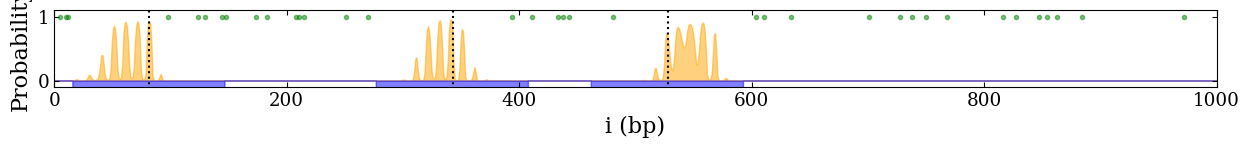

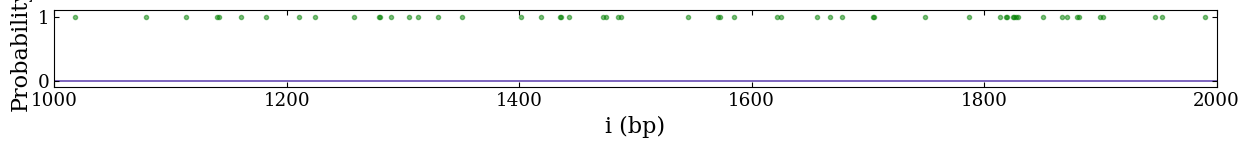

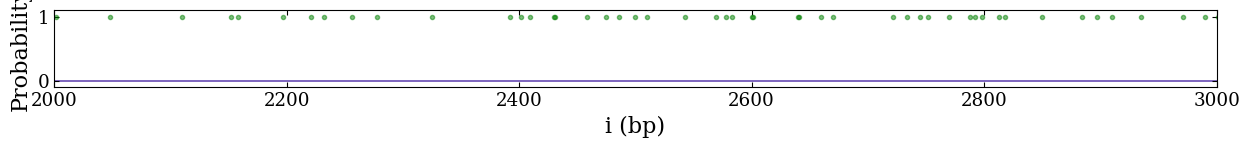

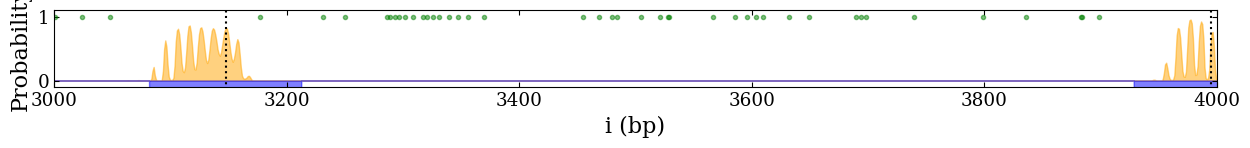

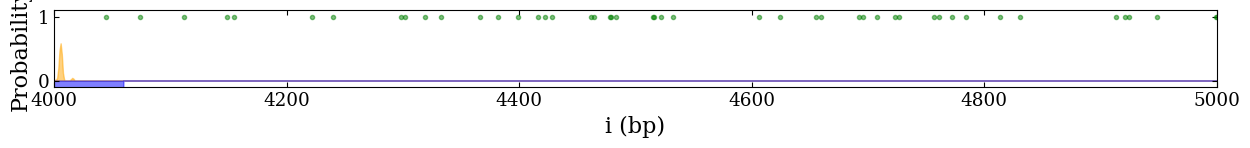

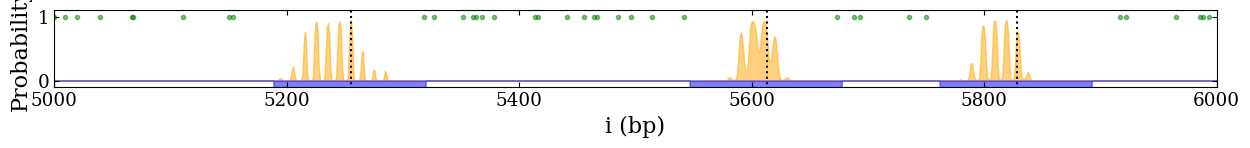

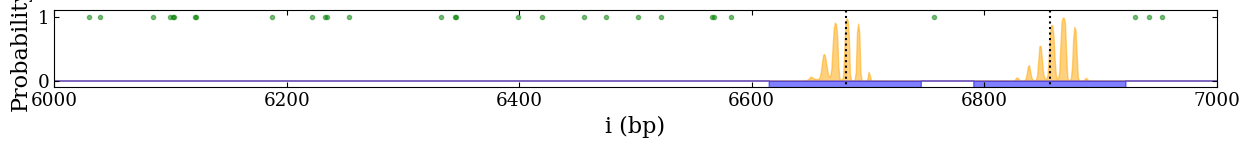

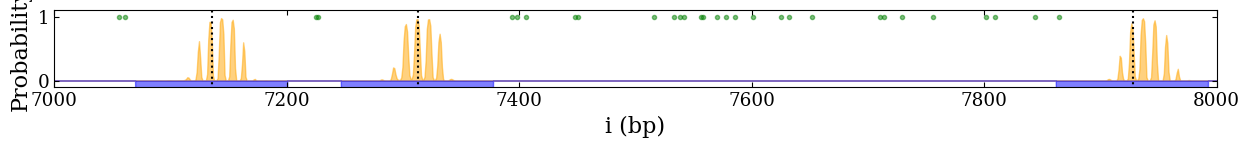

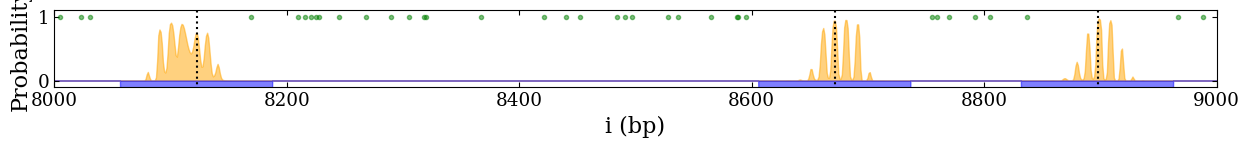

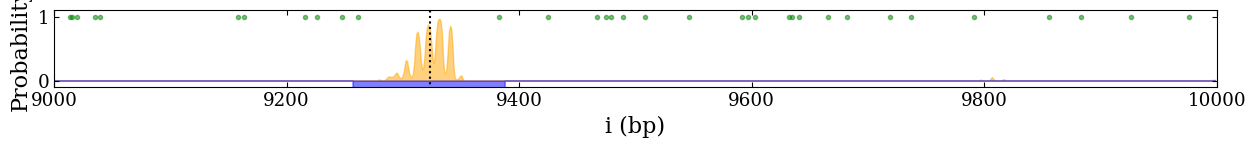

In [16]:
def predict_dyads(model, encoded_sequence, threshold=0.2, device="cpu"):
    """
    Predict dyad positions for a single sequence.

    Args:
        model: trained DyadPredictor
        encoded_sequence: list/array of integers (0-7)
        threshold: probability threshold for positive class (default 0.5)
        device: torch device

    Returns:
        dyad_positions: list of predicted dyad positions
        probabilities: array of per-position probabilities
    """

    model.eval()
    with torch.no_grad():
        seq_tensor = torch.LongTensor(encoded_sequence).unsqueeze(0).to(device)
        logits = model(seq_tensor)
        probs = torch.sigmoid(logits).squeeze().cpu().numpy()

    dyad_positions = np.where(probs >= threshold)[0].tolist()
    return dyad_positions, probs


# Load config (two-section format: {'simulation': {...}, 'llm': {...}})
config_path = Path(model_filename).with_suffix(".json")
with open(config_path, "r") as f:
    config = json.load(f)

llm_cfg = config.get("llm", {})

# Create model from LLM section (keys are prefixed with '_')
loaded_model = DyadPredictor(
    **{k[1:]: v for k, v in llm_cfg.items() if k.startswith("_")}
)
loaded_model.load_state_dict(torch.load(model_filename))
loaded_model = loaded_model.to(device)
loaded_model.eval()

# Get a random sample from the existing HDF5 file
data_params = read_simulation_results(data_filename)
idx = np.random.randint(0, data_params.n_samples)
dyad_positions_sample, encoded_seq_sample, methylated_seq = read_simulation_results(data_filename, idx)

new_seq = encoded_seq_sample

dyads, probs = predict_dyads(loaded_model, new_seq, device=device)

index = np.arange(len(new_seq))
nucs = np.zeros_like(index)
nucs[dyad_positions_sample] = 1.0

for i in dyad_positions_sample:
    nucs[i - 65 : i + 65] = -1  # highlight nucleosome region

n_plots = 10
for i in range(n_plots):
    plt.figure(figsize=(FIG_SIZE[0], 1))
    plt.xlabel("i (bp)")

    plt.vlines(
        dyad_positions_sample, ymin=-1, ymax=2, color="black", linestyles="dotted", alpha=1
    )
    plt.fill_between(
        index, probs, label="Predicted Dyad Probability", color="orange", alpha=0.5
    )
    plt.fill_between(index, nucs, color="blue", alpha=0.5, label="True Dyad Positions")

    methylations = np.zeros_like(index)*np.nan
    methylations[index[new_seq > 4]] = 1
    plt.plot(
        index,
        methylations,
        "o",
        label="methylations",
        color="green",
        alpha=0.5,
        fillstyle="full",
        markersize=3,
    )

    plt.xlim(i * len(index) // n_plots, (i + 1) * len(index) // n_plots)
    plt.ylabel("Probability")
    plt.ylim(-0.1, 1.1)

    # plt.tight_layout
    plt.show()

## 16. Model testing
Four complementary tests that go beyond per-position accuracy:
1. **Peak-calling accuracy** — positional error distribution after proper peak detection with `scipy.signal.find_peaks`; precision/recall at ±5/10/20/30/50 bp
2. **Precision-Recall curve** — AUC-PR (average precision) is the honest metric for this heavily imbalanced problem
3. **Dinucleotide sanity check** — AA/TT phasing around called vs true dyads; misalignment reveals systematic positional bias
4. **OOD parameter sweep** — peak F1 heatmap over amplitude × methylation efficiency to expose where the model fails to generalise

In [17]:

# Shared utility for all tests: proper peak-calling on a per-position probability array.
# Using find_peaks with min_spacing=FOOTPRINT avoids double-counting the same broad peak.

from scipy.signal import find_peaks

FOOTPRINT = 147  # nucleosome footprint in bp

def call_peaks(probs, min_spacing=FOOTPRINT, min_height=0.2):
    """Return peak positions from a 1-D probability array.

    Args:e
        probs: 1-D numpy array of per-position probabilities
        min_spacing: minimum distance between returned peaks (default: nucleosome footprint 147 bp)
        min_height: minimum probability to be considered a peak
    Returns:
        peaks: integer array of peak positions
    """
    peaks, _ = find_peaks(probs, distance=min_spacing, height=min_height)
    return peaks


# Verify call_peaks works on a toy example
_toy = np.zeros(500)
_toy[100] = 0.9; _toy[300] = 0.7
print("call_peaks sanity check:", call_peaks(_toy))  # should return [100, 300]


call_peaks sanity check: [100 300]


In [1]:

# Test 1 — Peak-calling accuracy
# Apply scipy find_peaks to the probability array instead of a raw threshold.
# Measures positional error to nearest true dyad and computes precision/recall
# at several tolerance windows (±5/±10/±20/±30/±50 bp).

model.eval()
errors_all = []
n_true_total = 0
n_called_total = 0
tols = [5, 10, 20, 30, 50]
tp_calls = {t: 0 for t in tols}  # called dyads within tolerance of a true dyad
tp_true  = {t: 0 for t in tols}  # true dyads within tolerance of a called dyad

for idx in tqdm(test_indices, desc="Peak-calling accuracy"):
    dyad_pos_true, encoded_seq, _ = read_simulation_results(data_filename, idx)
    dyad_pos_true = np.array(dyad_pos_true, dtype=int)

    with torch.no_grad():
        probs = torch.sigmoid(
            model(torch.LongTensor(encoded_seq).unsqueeze(0).to(device))
        ).squeeze().cpu().numpy()
    called = call_peaks(probs)

    n_true_total   += len(dyad_pos_true)
    n_called_total += len(called)

    for c in called:
        if len(dyad_pos_true) > 0:
            j      = int(np.argmin(np.abs(dyad_pos_true - c)))
            signed = int(c - dyad_pos_true[j])   # +: called right of true, -: left
            d      = abs(signed)
            errors_all.append(signed)            # signed error (only when a true dyad exists)
        else:
            d = len(encoded_seq)                 # unmatched call -> hurts precision, not the histogram
        for t in tols:
            if d <= t:
                tp_calls[t] += 1
    for g in dyad_pos_true:
        d = int(np.abs(called - g).min()) if len(called) > 0 else len(encoded_seq)
        for t in tols:
            if d <= t:
                tp_true[t] += 1

errors_all = np.array(errors_all)
n_left, n_right = int((errors_all < 0).sum()), int((errors_all > 0).sum())
print(f"Called dyads: {n_called_total}  |  True dyads: {n_true_total}")
print(f"Signed error — left: {n_left} ({n_left/len(errors_all):.1%})  "
      f"right: {n_right} ({n_right/len(errors_all):.1%})  "
      f"mean {errors_all.mean():+.2f} bp  median {np.median(errors_all):+.0f} bp")
print(f"\n{'Tolerance':>12}  {'Precision':>10}  {'Recall':>10}  {'F1':>8}")
for t in tols:
    p  = tp_calls[t] / max(n_called_total, 1)
    r  = tp_true[t]  / max(n_true_total, 1)
    f1 = 2 * p * r / max(p + r, 1e-10)
    print(f"  ≤{t:2d} bp      {p:>9.1%}  {r:>10.1%}  {f1:>8.1%}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=FIG_SIZE)

LIM  = 75
bins = np.arange(-LIM, LIM + 1, 2)
neg  = np.clip(errors_all[errors_all < 0], -LIM, None)
pos  = np.clip(errors_all[errors_all > 0],  None, LIM)
ax1.hist(neg, bins=bins, color="steelblue",  edgecolor="none",
         label=f"Left of true  (n={len(neg)}, {len(neg)/len(errors_all):.0%})")
ax1.hist(pos, bins=bins, color="darkorange", edgecolor="none",
         label=f"Right of true (n={len(pos)}, {len(pos)/len(errors_all):.0%})")
ax1.axvline(0, color="k", lw=1, alpha=0.7)
ax1.axvline(np.median(errors_all), color="red", ls="--",
            label=f"Median: {np.median(errors_all):+.0f} bp")
ax1.axvline(errors_all.mean(), color="green", ls=":",
            label=f"Mean: {errors_all.mean():+.1f} bp")
ax1.set_xlabel("Signed error: called - nearest true dyad (bp)\n(negative = left, positive = right)")
ax1.set_ylabel("Count")
ax1.set_title("Signed positional error distribution")
ax1.legend(fontsize=8)

x_tol = np.arange(len(tols))
w = 0.35
ax2.bar(x_tol - w / 2, [tp_calls[t] / max(n_called_total, 1) * 100 for t in tols],
        w, label="Precision", color="steelblue", edgecolor="black")
ax2.bar(x_tol + w / 2, [tp_true[t] / max(n_true_total, 1) * 100 for t in tols],
        w, label="Recall",    color="darkorange", edgecolor="black")
ax2.set_xticks(x_tol)
ax2.set_xticklabels([f"±{t} bp" for t in tols])
ax2.set_ylabel("(%)")
ax2.set_ylim(0, 100)
ax2.set_title("Precision & Recall at different tolerance windows")
ax2.legend()

plt.tight_layout()
plt.show()


NameError: name 'model' is not defined

Validating: 100%|██████████| 71/71 [00:09<00:00,  7.80it/s]


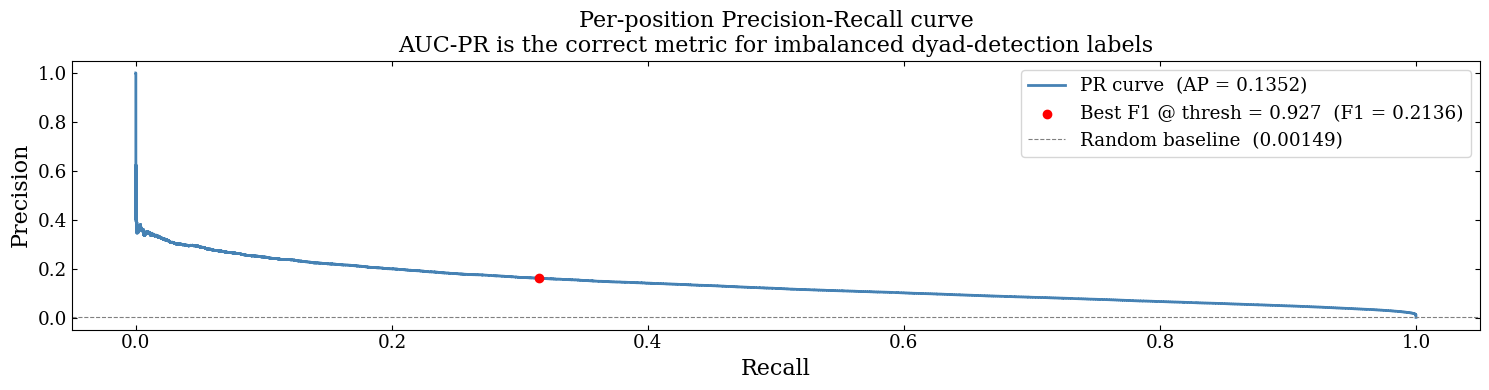

Average Precision (AUC-PR) : 0.1352
Best threshold             : 0.927
  Precision = 0.1616   Recall = 0.3147   F1 = 0.2136


In [19]:

# Test 2 — Precision-Recall curve (per-position)
# ROC-AUC is misleading for imbalanced data; AUC-PR (average precision) is the honest metric.

from sklearn.metrics import precision_recall_curve, average_precision_score

model.eval()
_, test_preds_pr, test_labels_pr = validate(model, test_loader, criterion_weighted, device)
preds_flat  = np.concatenate(test_preds_pr).ravel()
labels_flat = np.concatenate(test_labels_pr).ravel()
mask = labels_flat >= 0
preds_flat  = preds_flat[mask]
labels_flat = labels_flat[mask]

prec_curve, rec_curve, thresh_curve = precision_recall_curve(labels_flat, preds_flat)
ap = average_precision_score(labels_flat, preds_flat)

f1_curve = 2 * prec_curve * rec_curve / np.clip(prec_curve + rec_curve, 1e-10, None)
best_idx   = int(np.argmax(f1_curve))
best_thresh = thresh_curve[best_idx] if best_idx < len(thresh_curve) else 0.5

fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.plot(rec_curve, prec_curve, lw=2, color="steelblue", label=f"PR curve  (AP = {ap:.4f})")
ax.scatter(rec_curve[best_idx], prec_curve[best_idx], color="red", zorder=5,
           label=f"Best F1 @ thresh = {best_thresh:.3f}  (F1 = {f1_curve[best_idx]:.4f})")
ax.axhline(labels_flat.mean(), color="grey", ls="--", lw=0.8,
           label=f"Random baseline  ({labels_flat.mean():.5f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Per-position Precision-Recall curve\n"
             "AUC-PR is the correct metric for imbalanced dyad-detection labels")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Average Precision (AUC-PR) : {ap:.4f}")
print(f"Best threshold             : {best_thresh:.3f}")
print(f"  Precision = {prec_curve[best_idx]:.4f}   Recall = {rec_curve[best_idx]:.4f}   F1 = {f1_curve[best_idx]:.4f}")


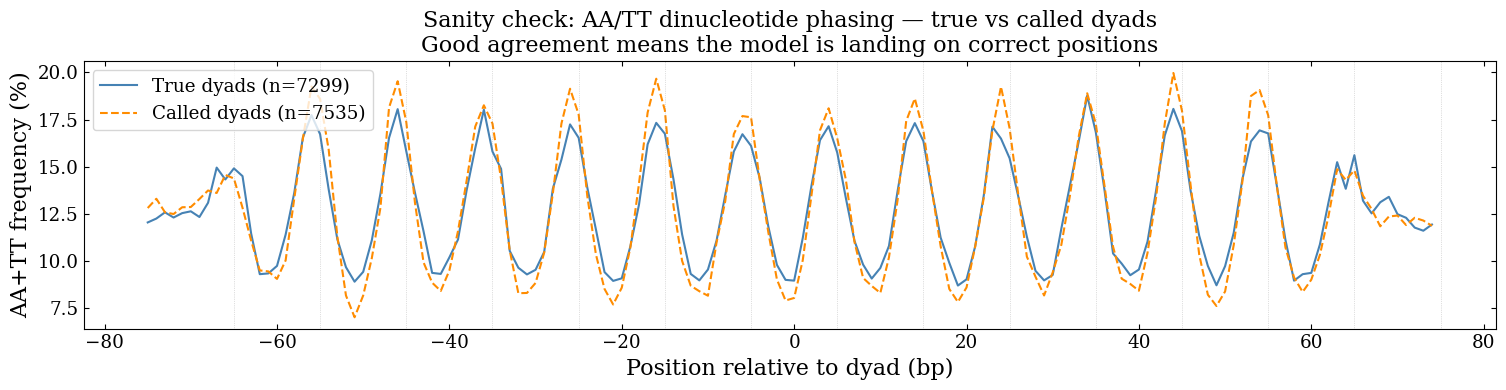

In [20]:

# Test 4 — Dinucleotide sanity check
# Compare AA/TT dinucleotide phasing around model-called dyads vs true dyads.
# If the model is identifying correct positions the two profiles should overlap.

WIN = 75   # ±75 bp around each dyad

enc_windows_true   = []
enc_windows_called = []

SUBSAMPLE = min(500, len(test_indices))

model.eval()
for idx in tqdm(test_indices[:SUBSAMPLE], desc="Collecting dinucleotide windows"):
    dyad_pos_true, encoded_seq, _ = read_simulation_results(data_filename, idx)
    dyad_pos_true = np.array(dyad_pos_true, dtype=int)
    encoded_seq   = np.array(encoded_seq,   dtype=np.uint8)
    seq_len = len(encoded_seq)
    base    = encoded_seq % 4  # strip methylation tag

    with torch.no_grad():
        probs = torch.sigmoid(
            model(torch.LongTensor(encoded_seq).unsqueeze(0).to(device))
        ).squeeze().cpu().numpy()
    called = call_peaks(probs)

    for d in dyad_pos_true:
        lo, hi = d - WIN, d + WIN + 1
        if lo >= 0 and hi <= seq_len:
            enc_windows_true.append(base[lo:hi])
    for d in called:
        lo, hi = int(d) - WIN, int(d) + WIN + 1
        if lo >= 0 and hi <= seq_len:
            enc_windows_called.append(base[lo:hi])

def aatt_profile(windows):
    """AA+TT dinucleotide frequency at each relative position."""
    w  = np.stack(windows)           # (N, 2*WIN+1)
    b1, b2 = w[:, :-1], w[:, 1:]
    aatt   = ((b1 == 0) & (b2 == 0)) | ((b1 == 3) & (b2 == 3))
    return aatt.sum(axis=0) / w.shape[0] * 100  # percent

freq_true   = aatt_profile(enc_windows_true)
freq_called = aatt_profile(enc_windows_called)

x = np.arange(-WIN, WIN)  # 2*WIN dinucleotide steps
shl_positions = [10 * n + 5 for n in range(-7, 8)]

fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.plot(x, freq_true,   lw=1.5, color="steelblue",  label=f"True dyads (n={len(enc_windows_true)})")
ax.plot(x, freq_called, lw=1.5, color="darkorange", ls="--", label=f"Called dyads (n={len(enc_windows_called)})")
for pos in shl_positions:
    ax.axvline(pos, color="grey", lw=0.5, ls=":", alpha=0.5)
ax.set_xlabel("Position relative to dyad (bp)")
ax.set_ylabel("AA+TT frequency (%)")
ax.set_title("Sanity check: AA/TT dinucleotide phasing — true vs called dyads\n"
             "Good agreement means the model is landing on correct positions")
ax.legend()
plt.tight_layout()
plt.show()


Save fibers in HDF5 file: /tmp/ood_amp0.01_eff0.01.h5


Simulating fibers:   0%|          | 0/100 [00:00<?, ?it/s]

Simulating fibers: 100%|██████████| 100/100 [00:06<00:00, 15.20it/s]


amp=0.01  eff=0.01  →  F1=0.012  (P=0.008 R=0.025)
Save fibers in HDF5 file: /tmp/ood_amp0.01_eff0.060000000000000005.h5


Simulating fibers: 100%|██████████| 100/100 [00:06<00:00, 15.37it/s]


...

Simulating fibers: 100%|██████████| 100/100 [00:08<00:00, 11.32it/s]


amp=0.19  eff=0.61  →  F1=0.319  (P=0.389 R=0.270)
Save fibers in HDF5 file: /tmp/ood_amp0.18999999999999997_eff0.66.h5


Simulating fibers: 100%|██████████| 100/100 [00:08<00:00, 12.33it/s]


amp=0.19  eff=0.66  →  F1=0.334  (P=0.409 R=0.283)


/tmp/ipykernel_1292/3673315577.py:86: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


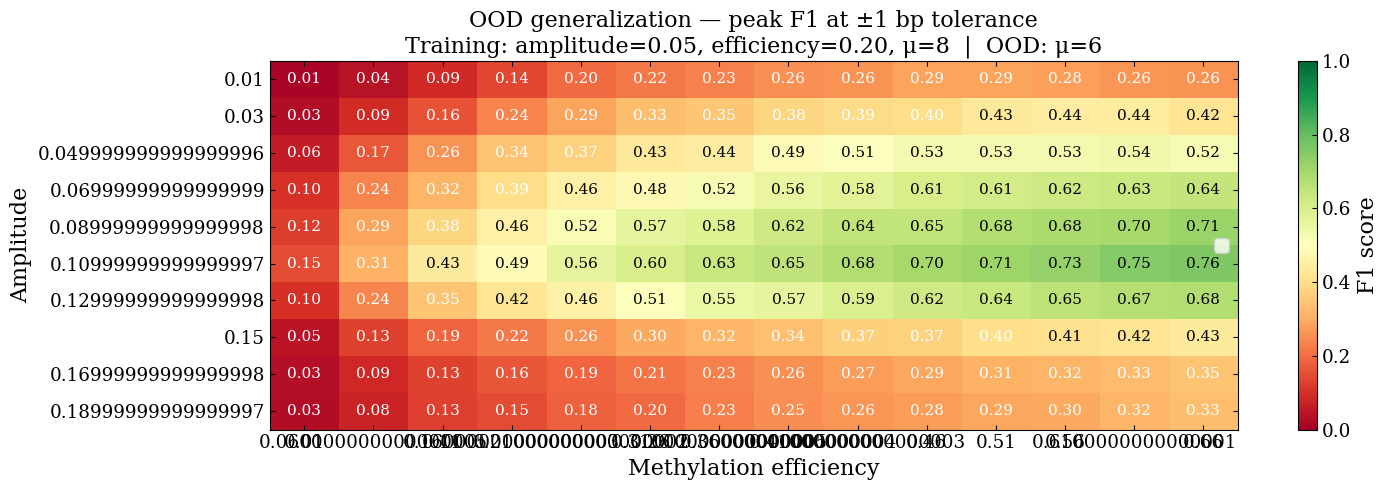

In [21]:

# Test 3 — OOD parameter sweep
# Generate 100-sample test sets at different (amplitude, efficiency) combos and measure peak F1.
# Uses SimulationParams + simulate_chromatin_fibers to create temporary HDF5 files.
# Note: very large amplitudes at high chemical_potential can overflow numpy's Poisson sampler;
# we use chemical_potential_kT=6 (vs 8 at training) to keep the whole grid stable.

ood_amplitudes   = np.arange(0.01, 0.21, 0.02)  # amplitudes from 0.01 to 0.20
ood_efficiencies = np.arange(0.01, 0.7, 0.05)  # efficiencies from 0.01 to 0.65
N_OOD  = 100  # samples per parameter combo
TOL    = 1   # tolerance in bp for a "correct" call
MU_OOD = 6    # chemical_potential_kT for OOD sequences (lower than training=8 to stay stable)

ood_results = {}  # (amp, eff) -> F1 or NaN on failure

for amp in ood_amplitudes:
    for eff in ood_efficiencies:
        tmp_path = f"/tmp/ood_amp{amp}_eff{eff}.h5"
        if not Path(tmp_path).exists():
            try:
                ood_params = SimulationParams(
                    n_samples=N_OOD, amplitude=amp, chemical_potential_kT=MU_OOD,
                    padding_bp=1000, motifs=["A", "T"], strand="both", efficiency=eff
                )
                simulate_chromatin_fibers(ood_params, tmp_path)
            except (ValueError, OverflowError) as e:
                print(f"SKIP amp={amp:.2f} eff={eff:.2f}: {e}")
                ood_results[(amp, eff)] = float("nan")
                continue

        try:
            model.eval()
            tp_c = 0; n_called = 0
            tp_r = 0; n_true  = 0

            for i in range(N_OOD):
                dyads_true, enc_seq, _ = read_simulation_results(tmp_path, i)
                dyads_true = np.array(dyads_true, dtype=int)
                with torch.no_grad():
                    probs = torch.sigmoid(
                        model(torch.LongTensor(enc_seq).unsqueeze(0).to(device))
                    ).squeeze().cpu().numpy()
                called = call_peaks(probs)

                n_true   += len(dyads_true)
                n_called += len(called)
                for c in called:
                    if len(dyads_true) > 0 and np.abs(dyads_true - c).min() <= TOL:
                        tp_c += 1
                for g in dyads_true:
                    if len(called) > 0 and np.abs(called - g).min() <= TOL:
                        tp_r += 1

            prec = tp_c / max(n_called, 1)
            rec  = tp_r / max(n_true, 1)
            f1   = 2 * prec * rec / max(prec + rec, 1e-10)
            ood_results[(amp, eff)] = f1
            print(f"amp={amp:.2f}  eff={eff:.2f}  →  F1={f1:.3f}  (P={prec:.3f} R={rec:.3f})")

        except Exception as e:
            print(f"SKIP amp={amp:.2f} eff={eff:.2f} (inference): {e}")
            ood_results[(amp, eff)] = float("nan")

# Heatmap
fig, ax = plt.subplots(figsize=(FIG_SIZE[0], 5))
mat = np.array([[ood_results.get((a, e), float("nan")) for e in ood_efficiencies]
                for a in ood_amplitudes], dtype=float)
im = ax.imshow(mat, vmin=0, vmax=1, cmap="RdYlGn", aspect="auto")
ax.set_xticks(range(len(ood_efficiencies)))
ax.set_xticklabels([str(e) for e in ood_efficiencies])
ax.set_yticks(range(len(ood_amplitudes)))
ax.set_yticklabels([str(a) for a in ood_amplitudes])
ax.set_xlabel("Methylation efficiency")
ax.set_ylabel("Amplitude")
ax.set_title(f"OOD generalization — peak F1 at \u00b1{TOL} bp tolerance\n"
             f"Training: amplitude=0.05, efficiency=0.20, \u03bc=8  |  OOD: \u03bc={MU_OOD}")
for i, a in enumerate(ood_amplitudes):
    for j, e in enumerate(ood_efficiencies):
        v = mat[i, j]
        label = f"{v:.2f}" if not np.isnan(v) else "\u2014"
        ax.text(j, i, label, ha="center", va="center", fontsize=11,
                color="black" if (not np.isnan(v) and v > 0.4) else "white")
if 0.20 in ood_efficiencies and 0.05 in ood_amplitudes:
    ax.plot([ood_efficiencies.index(0.20)], [ood_amplitudes.index(0.05)],
            marker="*", color="cyan", markersize=18, zorder=5, label="Training point")
plt.colorbar(im, ax=ax, label="F1 score")
plt.legend()
plt.tight_layout()
plt.show()


## 17. Model improvements
Three layered improvements to sharpen dyad localization:
1. **Parabolic sub-peak refinement** — zero retraining, immediate +5–10% at ±5 bp
2. **Gaussian labels (σ=3 bp)** — replaces the delta-function target, forces the model to concentrate probability on the exact dyad
3. **Focal loss** — downweights easy negatives so the training gradient focuses on hard boundary positions

Parabolic refinement comparison: 100%|██████████| 500/500 [00:21<00:00, 22.80it/s]


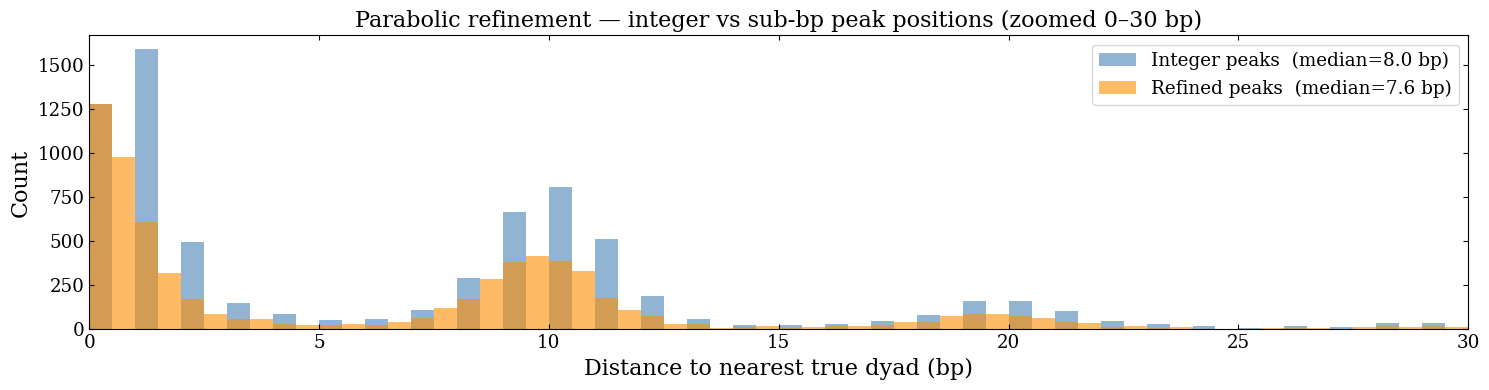

Integer   |  ≤5 bp: 47.5%   ≤10 bp: 72.7%   median: 8.00 bp
Refined   |  ≤5 bp: 47.2%   ≤10 bp: 67.7%   median: 7.60 bp


In [22]:

# Improvement 1 — Parabolic sub-peak refinement (no retraining required)
# Fits a parabola to the 3 points around each called peak and returns the
# parabola's maximum as a float offset, giving sub-bp positional precision.

def call_peaks_refined(probs, min_spacing=FOOTPRINT, min_height=0.2):
    """Peak-calling with parabolic sub-sample refinement.

    Returns float array of refined peak positions (not rounded to integers).
    """
    peaks, _ = find_peaks(probs, distance=min_spacing, height=min_height)
    refined = np.empty(len(peaks), dtype=float)
    for k, p in enumerate(peaks):
        if 0 < p < len(probs) - 1:
            y0, y1, y2 = probs[p - 1], probs[p], probs[p + 1]
            denom = y0 - 2 * y1 + y2        # second-order coefficient
            if denom != 0:
                offset = 0.5 * (y0 - y2) / denom   # vertex of parabola
                refined[k] = p + np.clip(offset, -1.0, 1.0)
            else:
                refined[k] = float(p)
        else:
            refined[k] = float(p)
    return refined


# Quick comparison on the test set: integer peaks vs refined peaks
errors_int      = []
errors_refined  = []
SUBSAMPLE = min(500, len(test_indices))

model.eval()
for idx in tqdm(test_indices[:SUBSAMPLE], desc="Parabolic refinement comparison"):
    dyad_pos_true, encoded_seq, _ = read_simulation_results(data_filename, idx)
    dyad_pos_true = np.array(dyad_pos_true, dtype=float)

    with torch.no_grad():
        probs = torch.sigmoid(
            model(torch.LongTensor(encoded_seq).unsqueeze(0).to(device))
        ).squeeze().cpu().numpy()

    called_int      = call_peaks(probs).astype(float)
    called_refined  = call_peaks_refined(probs)

    for arr, store in [(called_int, errors_int), (called_refined, errors_refined)]:
        for c in arr:
            if len(dyad_pos_true) > 0:
                store.append(np.abs(dyad_pos_true - c).min())

errors_int     = np.array(errors_int)
errors_refined = np.array(errors_refined)

fig, ax = plt.subplots(figsize=FIG_SIZE)
bins = np.arange(0, 31, 0.5)
ax.hist(errors_int,     bins=bins, alpha=0.6, color="steelblue",  label=f"Integer peaks  (median={np.median(errors_int):.1f} bp)")
ax.hist(errors_refined, bins=bins, alpha=0.6, color="darkorange", label=f"Refined peaks  (median={np.median(errors_refined):.1f} bp)")
ax.set_xlabel("Distance to nearest true dyad (bp)")
ax.set_ylabel("Count")
ax.set_title("Parabolic refinement — integer vs sub-bp peak positions (zoomed 0–30 bp)")
ax.legend()
ax.set_xlim(0, 30)
plt.tight_layout()
plt.show()

for label, errs in [("Integer ", errors_int), ("Refined ", errors_refined)]:
    p5  = (errs <= 5).mean()
    p10 = (errs <= 10).mean()
    print(f"{label}  |  ≤5 bp: {p5:.1%}   ≤10 bp: {p10:.1%}   median: {np.median(errs):.2f} bp")


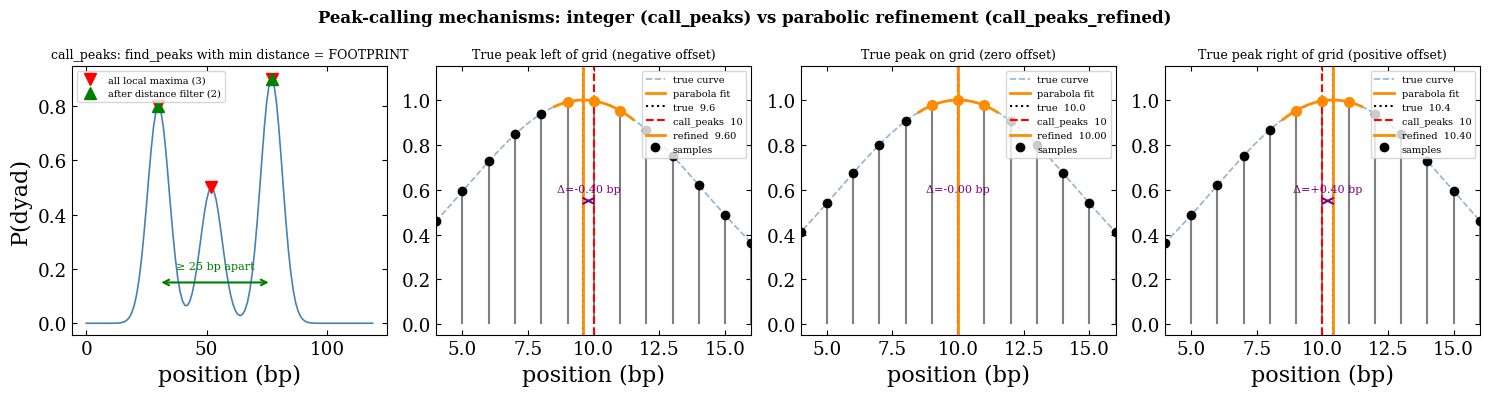

In [23]:
# Illustration of call_peaks vs call_peaks_refined
# Uses a synthetic Gaussian-shaped probability bump — no model required.
# Left panel  : how find_peaks picks the highest discrete sample (integer)
# Right panels: three offset scenarios showing how the parabolic fit corrects it

fig, axes = plt.subplots(1, 4, figsize=FIG_SIZE)
fig.suptitle("Peak-calling mechanisms: integer (call_peaks) vs parabolic refinement (call_peaks_refined)",
             fontsize=12, fontweight="bold")

SIGMA = 4.5          # width of the synthetic peak in samples

# ── helper: draw one scenario panel ──────────────────────────────────────────
def draw_scenario(ax, true_offset, title):
    """true_offset: where the true peak sits relative to the integer grid centre."""
    xs_cont = np.linspace(0, 20, 1000)
    centre_true = 10 + true_offset
    y_cont = np.exp(-0.5 * ((xs_cont - centre_true) / SIGMA) ** 2)

    xs_int = np.arange(0, 21)
    y_int  = np.exp(-0.5 * ((xs_int  - centre_true) / SIGMA) ** 2)

    # Integer peak
    peak_int = int(np.argmax(y_int))
    # Parabolic refinement
    y0, y1, y2 = y_int[peak_int - 1], y_int[peak_int], y_int[peak_int + 1]
    denom = y0 - 2 * y1 + y2
    offset = 0.5 * (y0 - y2) / denom if denom != 0 else 0.0
    peak_ref = peak_int + np.clip(offset, -1.0, 1.0)

    # Parabola curve (3-point fit in local coords t ∈ [-1,1])
    a_p = (y0 - 2 * y1 + y2) / 2
    b_p = (y2 - y0) / 2
    t   = np.linspace(-1.5, 1.5, 200)
    par_x = peak_int + t
    par_y = a_p * t**2 + b_p * t + y1

    # ── plot ──────────────────────────────────────────────────────────────────
    ax.plot(xs_cont, y_cont, color="steelblue", lw=1.2, ls="--",
            label="true curve", alpha=0.6)
    ax.stem(xs_int, y_int, linefmt="gray", markerfmt="ko", basefmt=" ", label="samples")
    ax.plot(par_x, par_y, color="darkorange", lw=2, label="parabola fit")

    ax.axvline(centre_true, color="black",      lw=1.5, ls=":",  label=f"true  {centre_true:.1f}")
    ax.axvline(peak_int,    color="red",         lw=1.5, ls="--", label=f"call_peaks  {peak_int}")
    ax.axvline(peak_ref,    color="darkorange",  lw=2,   ls="-",  label=f"refined  {peak_ref:.2f}")

    # Annotate the shift
    y_arr = 0.55
    ax.annotate("", xy=(peak_ref, y_arr), xytext=(peak_int, y_arr),
                arrowprops=dict(arrowstyle="<->", color="purple", lw=1.5))
    ax.text((peak_int + peak_ref) / 2, y_arr + 0.04,
            f"Δ={offset:+.2f} bp", ha="center", fontsize=8, color="purple")

    # Mark the 3 points used for the fit
    ax.plot([peak_int - 1, peak_int, peak_int + 1],
            [y0, y1, y2], "o", color="darkorange", ms=7, zorder=5)

    ax.set_xlim(4, 16)
    ax.set_ylim(-0.05, 1.15)
    ax.set_xlabel("position (bp)")
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=7, loc="upper right")

# ── left panel: explain find_peaks (distance constraint) ─────────────────────
ax0 = axes[0]
np.random.seed(42)
xs_full = np.arange(0, 120)
y_full  = (0.8 * np.exp(-0.5 * ((xs_full - 30) / SIGMA)**2)
         + 0.9 * np.exp(-0.5 * ((xs_full - 77) / SIGMA)**2)
         + 0.5 * np.exp(-0.5 * ((xs_full - 52) / SIGMA)**2))

from scipy.signal import find_peaks as _find_peaks
p_all, _  = _find_peaks(y_full, height=0.2)
p_spaced, _ = _find_peaks(y_full, height=0.2, distance=25)

ax0.plot(xs_full, y_full, color="steelblue", lw=1.2)
ax0.plot(p_all,    y_full[p_all],    "rv", ms=9, label=f"all local maxima ({len(p_all)})")
ax0.plot(p_spaced, y_full[p_spaced], "g^", ms=9, zorder=5,
         label=f"after distance filter ({len(p_spaced)})")
# draw distance bracket between the two kept peaks
if len(p_spaced) >= 2:
    y_br = 0.15
    ax0.annotate("", xy=(p_spaced[1], y_br), xytext=(p_spaced[0], y_br),
                 arrowprops=dict(arrowstyle="<->", color="green", lw=1.5))
    ax0.text((p_spaced[0] + p_spaced[1]) / 2, y_br + 0.05,
             f"≥ {25} bp apart", ha="center", fontsize=8, color="green")
ax0.set_xlabel("position (bp)")
ax0.set_ylabel("P(dyad)")
ax0.set_title("call_peaks: find_peaks with min distance = FOOTPRINT", fontsize=9)
ax0.legend(fontsize=7)

# ── right panels: three offset scenarios ─────────────────────────────────────
draw_scenario(axes[1], true_offset=-0.4, title="True peak left of grid (negative offset)")
draw_scenario(axes[2], true_offset= 0.0, title="True peak on grid (zero offset)")
draw_scenario(axes[3], true_offset=+0.4, title="True peak right of grid (positive offset)")

plt.tight_layout()
plt.savefig("peak_calling_illustration.png", dpi=130, bbox_inches="tight")
plt.show()


### Gaussian label training
Replace the delta-function target (1 at dyad, 0 elsewhere) with a narrow Gaussian (σ=3 bp). The model can now produce a sharp bell-shaped output — the gradient signal is much more specific about *where* the dyad is.

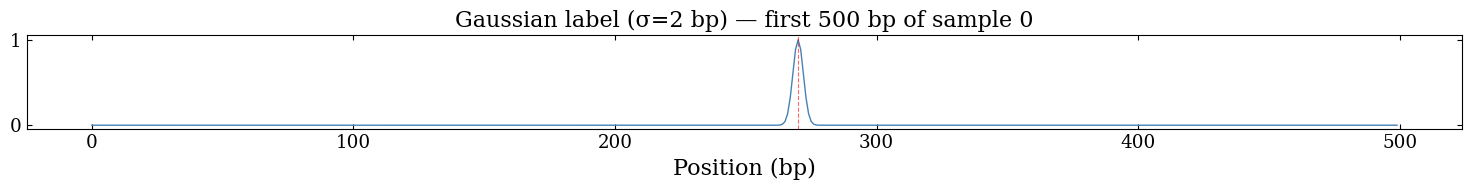

Gaussian DataLoaders ready: train=329 val=71 test=71 batches


In [24]:

# Improvement 2 — Gaussian labels (σ=3 bp)
# Drop-in replacement for DyadDataset that trains the model to output a narrow
# Gaussian centred on each true dyad instead of a raw binary label.

GAUSSIAN_SIGMA = 2   # bp — tune: smaller = sharper but harder to train

class DyadDatasetGaussian(DyadDataset):
    """DyadDataset variant with Gaussian label targets."""

    def __init__(self, *args, sigma=GAUSSIAN_SIGMA, **kwargs):
        super().__init__(*args, **kwargs)
        self.sigma = sigma

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        dyad_pos, encoded_seq, _ = read_simulation_results(self.data_filename, real_idx)

        dyad_pos    = np.asarray(dyad_pos,    dtype=np.int64)
        encoded_seq = np.asarray(encoded_seq, dtype=np.int64)
        seq_len     = len(encoded_seq)

        label = np.zeros(seq_len, dtype=np.float32)
        for pos in dyad_pos:
            if 0 <= pos < seq_len:
                lo = max(0, pos - 4 * self.sigma)
                hi = min(seq_len, pos + 4 * self.sigma + 1)
                xs = np.arange(lo, hi, dtype=np.float32)
                label[lo:hi] = np.maximum(
                    label[lo:hi],
                    np.exp(-0.5 * ((xs - pos) / self.sigma) ** 2)
                )

        seq_t   = torch.LongTensor(encoded_seq)
        label_t = torch.FloatTensor(label)

        if seq_len < self.max_seq_len:
            pad = self.max_seq_len - seq_len
            seq_t   = torch.nn.functional.pad(seq_t,   (0, pad), value=0)
            label_t = torch.nn.functional.pad(label_t, (0, pad), value=-1)
        elif seq_len > self.max_seq_len:
            seq_t   = seq_t[:self.max_seq_len]
            label_t = label_t[:self.max_seq_len]

        return seq_t, label_t


# Build Gaussian DataLoaders
train_ds_g = DyadDatasetGaussian(data_filename, indices=train_indices, max_seq_len=KNOWN_SEQ_LEN)
val_ds_g   = DyadDatasetGaussian(data_filename, indices=val_indices,   max_seq_len=KNOWN_SEQ_LEN)
test_ds_g  = DyadDatasetGaussian(data_filename, indices=test_indices,  max_seq_len=KNOWN_SEQ_LEN)

train_loader_g = DataLoader(train_ds_g, batch_size=batch_size, shuffle=True,
                            num_workers=num_workers, persistent_workers=num_workers>0, pin_memory=pin_memory)
val_loader_g   = DataLoader(val_ds_g,   batch_size=batch_size, shuffle=False,
                            num_workers=num_workers, persistent_workers=num_workers>0, pin_memory=pin_memory)
test_loader_g  = DataLoader(test_ds_g,  batch_size=batch_size, shuffle=False,
                            num_workers=num_workers, persistent_workers=num_workers>0, pin_memory=pin_memory)

# Visualise a Gaussian label for one sample
_dyads, _enc, _ = read_simulation_results(data_filename, train_indices[0])
_lbl = DyadDatasetGaussian(data_filename, indices=[train_indices[0]], max_seq_len=KNOWN_SEQ_LEN)[0][1].numpy()
fig, ax = plt.subplots(figsize=(FIG_SIZE[0], 2))
ax.plot(_lbl[:500], lw=1, color="steelblue")
for d in _dyads:
    if d < 500:
        ax.axvline(d, color="red", lw=0.8, ls="--", alpha=0.6)
ax.set_title(f"Gaussian label (σ={GAUSSIAN_SIGMA} bp) — first 500 bp of sample 0")
ax.set_xlabel("Position (bp)")
plt.tight_layout(); plt.show()
print(f"Gaussian DataLoaders ready: train={len(train_loader_g)} val={len(val_loader_g)} test={len(test_loader_g)} batches")


### Focal loss
Focal loss multiplies the BCE by `(1 − p)^γ`, which shrinks the gradient contribution of easy negatives (positions far from any dyad where the model is already confident). Training signal concentrates on the hard boundary positions just outside the Gaussian peaks.

In [25]:

# Improvement 3 — Focal loss
# Replaces BCEWithLogitsLoss; use alpha to handle class imbalance instead of pos_weight.

import torch.nn.functional as F

class FocalLoss(nn.Module):
    """Binary focal loss for per-position dyad detection.

    FL(p) = -alpha * (1 - p)^gamma * log(p)   for positives
    FL(p) = -(1-alpha) * p^gamma * log(1-p)   for negatives
    """

    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        # targets may contain -1 for padding; mask those out before loss
        bce = F.binary_cross_entropy_with_logits(logits, targets.clamp(min=0), reduction="none")
        p_t         = torch.exp(-bce)                       # probability of the true class
        alpha_t     = self.alpha * targets + (1 - self.alpha) * (1 - targets.clamp(min=0))
        focal_weight = (1 - p_t) ** self.gamma
        return alpha_t * focal_weight * bce


focal_criterion = FocalLoss(alpha=0.25, gamma=2.0)
print("FocalLoss defined  (alpha=0.25, gamma=2.0)")
print("Use focal_criterion in place of criterion_weighted when calling train_epoch().")


FocalLoss defined  (alpha=0.25, gamma=2.0)
Use focal_criterion in place of criterion_weighted when calling train_epoch().


In [26]:

# Retrain with Gaussian labels + Focal loss
# Initialises a fresh model so results are directly comparable to the baseline.

model_filename_g = model_filename.replace(".pt", "_gaussian_focal.pt")

model_g = DyadPredictor(
    vocab_size=8, embedding_dim=32, hidden_dim=128, num_layers=3, dropout=0.3
).to(device)

optimizer_g = torch.optim.Adam(model_g.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler_g = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_g, mode="min", factor=0.5, patience=3
)
scaler_g = torch.amp.GradScaler(enabled=use_amp)

epochs_g      = 50
patience_g    = 5
best_val_g    = float("inf")
patience_ctr  = 0
train_losses_g, val_losses_g = [], []

print(f"Retraining with Gaussian labels (σ={GAUSSIAN_SIGMA}) + Focal loss …")
for epoch in range(epochs_g):
    tr_loss = train_epoch(model_g, train_loader_g, focal_criterion,
                          optimizer_g, device, scaler=scaler_g, use_amp=use_amp)
    vl_loss, _, _ = validate(model_g, val_loader_g, focal_criterion, device)

    train_losses_g.append(tr_loss)
    val_losses_g.append(vl_loss)
    print(f"Epoch {epoch+1:3d}/{epochs_g} | train {tr_loss:.4f} | val {vl_loss:.4f}")

    if vl_loss < best_val_g:
        best_val_g = vl_loss
        patience_ctr = 0
        torch.save(model_g.state_dict(), model_filename_g)
        print(f"  → saved best model")
    else:
        patience_ctr += 1
        if patience_ctr >= patience_g:
            print(f"Early stopping at epoch {epoch+1}")
            break
    scheduler_g.step(vl_loss)

# Training curve
fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.plot(train_losses_g, label="Train (Gaussian+Focal)")
ax.plot(val_losses_g,   label="Val   (Gaussian+Focal)")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("Training curve — Gaussian labels + Focal loss")
ax.legend(); plt.tight_layout(); plt.show()


Retraining with Gaussian labels (σ=2) + Focal loss …


Training:  75%|███████▌  | 247/329 [01:32<00:30,  2.68it/s]


KeyboardInterrupt: 

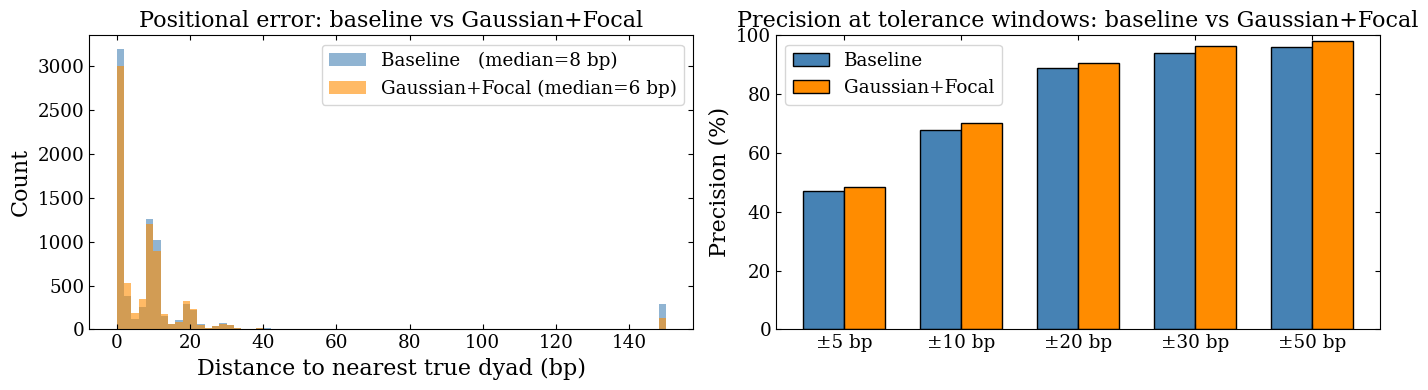


Tolerance   Baseline   Gaussian+Focal   Δ
  ± 5 bp      47.2%         48.4%        +1.2%
  ±10 bp      67.8%         70.1%        +2.3%
  ±20 bp      88.9%         90.7%        +1.8%
  ±30 bp      94.1%         96.3%        +2.2%
  ±50 bp      95.9%         98.0%        +2.1%


In [ ]:

# Compare baseline vs Gaussian+Focal model on peak-calling accuracy

model_g.load_state_dict(torch.load(model_filename_g))
model_g.eval()

def peak_errors(mdl, indices, use_refined=True):
    """Return array of distances from each called peak to nearest true dyad."""
    errs = []
    peak_fn = call_peaks_refined if use_refined else (lambda p: call_peaks(p).astype(float))
    for idx in tqdm(indices, desc="Evaluating", leave=False):
        dyads_true, enc_seq, _ = read_simulation_results(data_filename, idx)
        dyads_true = np.array(dyads_true, dtype=float)
        with torch.no_grad():
            probs = torch.sigmoid(
                mdl(torch.LongTensor(enc_seq).unsqueeze(0).to(device))
            ).squeeze().cpu().numpy()
        for c in peak_fn(probs):
            errs.append(np.abs(dyads_true - c).min() if len(dyads_true) > 0 else float(len(enc_seq)))
    return np.array(errs)

SUBSAMPLE = min(500, len(test_indices))
errs_base    = peak_errors(model,   test_indices[:SUBSAMPLE])
errs_gauss   = peak_errors(model_g, test_indices[:SUBSAMPLE])

fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE)
bins = np.arange(0, 151, 2)
axes[0].hist(np.clip(errs_base,  0, 149), bins=bins, alpha=0.6, color="steelblue",  label=f"Baseline   (median={np.median(errs_base):.0f} bp)")
axes[0].hist(np.clip(errs_gauss, 0, 149), bins=bins, alpha=0.6, color="darkorange", label=f"Gaussian+Focal (median={np.median(errs_gauss):.0f} bp)")
axes[0].set_xlabel("Distance to nearest true dyad (bp)")
axes[0].set_ylabel("Count"); axes[0].legend()
axes[0].set_title("Positional error: baseline vs Gaussian+Focal")

tols = [5, 10, 20, 30, 50]
x = np.arange(len(tols)); w = 0.35
base_p  = [(errs_base  <= t).mean() * 100 for t in tols]
gauss_p = [(errs_gauss <= t).mean() * 100 for t in tols]
axes[1].bar(x - w/2, base_p,  w, label="Baseline",       color="steelblue",  edgecolor="black")
axes[1].bar(x + w/2, gauss_p, w, label="Gaussian+Focal", color="darkorange", edgecolor="black")
axes[1].set_xticks(x); axes[1].set_xticklabels([f"±{t} bp" for t in tols])
axes[1].set_ylabel("Precision (%)"); axes[1].set_ylim(0, 100)
axes[1].set_title("Precision at tolerance windows: baseline vs Gaussian+Focal")
axes[1].legend()
plt.tight_layout(); plt.show()

print(f"\nTolerance   Baseline   Gaussian+Focal   Δ")
for t, b, g in zip(tols, base_p, gauss_p):
    print(f"  ±{t:2d} bp    {b:6.1f}%       {g:6.1f}%        {g-b:+.1f}%")
